# 06 — Resampling and Model Stability

This notebook moves the project from exploratory modeling into model validation and stability analysis.

The goal is to evaluate whether model performance is robust to:
- resampling variation
- time-aware train/test splits
- feature selection changes
- permutation-based feature sensitivity

This notebook also uses findings from prior analyses to define a cleaner final modeling dataset:
- reduced multicollinearity
- transformed heavy-tailed variables
- more stable and interpretable inputs

A key extension in this notebook is the comparison between:

- **PCA**, used previously as an unsupervised method to understand latent structure in the predictors
- **PCR**, used here as a supervised regression workflow built on principal components

This allows me to compare:
- hand-selected refined features
- principal-component-based regression
- flexible nonlinear models

across multiple targets under the same validation framework.

This notebook should answer:

How stable are the modeling results once we account for resampling, time-aware validation, and feature sensitivity?

And just as importantly:

Does the cleaned, transformed, reduced feature set actually improve reliability versus the original modeling dataset?

## 1. Final modeling dataset design

Build a clean, explicit final feature set using what we learned in 05:
- drop highly collinear variables
- keep one feature per signal cluster where appropriate
- transform skewed variables
- keep interpretable variables where possible

## 2. Stable modeling pipeline

Build a reusable pipeline with:
- preprocessing
- transformations
- optional scaling
- model
- evaluation

## 3. Resampling and validation

Include:
- bootstrap confidence intervals
- K-fold or repeated CV
- rolling-origin validation
- train/test window sensitivity

## 4. Robustness and interpretability

Include:
- permutation importance
- feature importance stability
- comparison across resamples

## 5. Pre vs post refinement comparison

Show whether the final feature set:
- improves performance
- improves stability
- improves interpretability


# targets 

primary: finish_position

secondary: optional target_points

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    explained_variance_score,
    make_scorer
)
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

np.random.seed(42)
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## Load Final Source Data

Use the pre-race feature store as the base for the final modeling dataset. This is the cleanest starting point for validating model stability because it avoids in-race leakage and preserves interpretable pre-race structure.

In [2]:
prerace = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
master = pd.read_parquet("data_processed/f1_feature_store_master.parquet")

print("Pre-race:", prerace.shape)
print("Master:", master.shape)

Pre-race: (26759, 49)
Master: (26759, 103)


## Define Original vs Refined Feature Sets

Compare the earlier broad modeling set with a refined version informed by:
- skewness and kurtosis diagnostics
- multicollinearity checks
- PCA and feature redundancy analysis

In [3]:
original_features = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "driver_standing_wins_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "constructor_standing_wins_prerace",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed",
    "is_wet_race"
]

refined_features = [
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "constructor_dnf_rate_last5",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed",
    "is_wet_race"
]

**Extending PCA into Prediction**

Notebook 05 used PCA to understand latent structure in the feature space and identify redundancy among engineered variables.

In this notebook, I carry that analysis into supervised learning by introducing Principal Component Regression (PCR).

This creates a useful distinction:

- **PCA** is an unsupervised method used to summarize structure in the predictors
- **PCR** is a supervised regression workflow that uses those principal components as model inputs

This allows me to compare:
- hand-selected refined features
- principal-component-based regression
- flexible nonlinear models

across multiple targets under the same validation framework.

## Define targets and build working dataset


In [4]:
TARGET_SPECS = {
    "finish_position": {
        "label": "Finish Position",
        "type": "regression"
    },
    "points": {
        "label": "Points Scored",
        "type": "regression"
    }
}

In [5]:
df = prerace.copy()

all_needed_cols = list(set(
    ["year"] +
    list(TARGET_SPECS.keys()) +
    original_features +
    refined_features
))

df = df[all_needed_cols].copy()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,points,grid_clean,driver_dnf_rate_last5,precipitation,qualifying_position,constructor_standing_points_prerace,constructor_dnf_rate_last5,driver_avg_grid_last5,driver_standing_position_prerace,finish_position,constructor_standing_wins_prerace,temp_avg,driver_standing_wins_prerace,year,is_wet_race,driver_points_last5,wind_speed,driver_standing_points_prerace,alt,constructor_standing_position_prerace,constructor_avg_finish_last5,driver_avg_finish_last5,constructor_points_last5
0,10.0,1.0,0.2,0.0,1.0,218.0,0.4,2.0,2.0,1,8.0,27.9,4.0,2008,0,25.0,23.1,109.0,10,11.0,10.4,6.6,16.0
1,8.0,5.0,0.2,0.0,5.0,101.0,0.4,5.8,5.0,2,0.0,27.9,0.0,2008,0,14.0,23.1,61.0,10,2.0,10.0,7.2,9.0
2,6.0,7.0,0.2,0.0,7.0,33.0,0.2,10.8,9.0,3,0.0,27.9,0.0,2008,0,11.0,23.1,20.0,10,4.0,12.8,10.0,5.0
3,5.0,11.0,0.2,0.0,12.0,51.0,0.4,2.8,3.0,4,0.0,27.9,4.0,2008,0,30.0,23.1,109.0,10,3.0,12.8,6.0,4.0
4,4.0,3.0,0.2,0.0,3.0,218.0,0.2,11.4,7.0,5,8.0,27.9,0.0,2008,0,11.0,23.1,30.0,10,11.0,6.4,8.6,26.0


## Preprocessing Pipelines

Use a robust preprocessing pipeline that:
- imputes missing values
- scales numeric variables
- optionally applies power transformations for skewed inputs

In [6]:
transformed_features = [
    "precipitation",
    "wind_speed"
]

numeric_original = original_features
numeric_refined = refined_features

preprocessor_original = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_original)
    ],
    remainder="drop"
)

preprocessor_refined = ColumnTransformer(
    transformers=[
        ("power", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("power", PowerTransformer(method="yeo-johnson")),
            ("scaler", StandardScaler())
        ]), transformed_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), [c for c in numeric_refined if c not in transformed_features])
    ],
    remainder="drop"
)

## Candidate Models

Compare a regularized linear baseline against a flexible tree-based model.

In [7]:
ridge_model = Ridge(alpha=1.0)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

In [8]:
ridge_pipeline_original = Pipeline([
    ("preprocess", preprocessor_original),
    ("model", ridge_model)
])

ridge_pipeline_refined = Pipeline([
    ("preprocess", preprocessor_refined),
    ("model", ridge_model)
])

pcr_pipeline_original = Pipeline([
    ("preprocess", preprocessor_original),
    ("pca", PCA(n_components=10)),
    ("model", LinearRegression())
])

pcr_pipeline_refined = Pipeline([
    ("preprocess", preprocessor_refined),
    ("pca", PCA(n_components=min(8, len(refined_features)))),
    ("model", LinearRegression())
])

xgb_pipeline_original = Pipeline([
    ("preprocess", preprocessor_original),
    ("model", xgb_model)
])

xgb_pipeline_refined = Pipeline([
    ("preprocess", preprocessor_refined),
    ("model", xgb_model)
])

In [9]:
MODEL_REGISTRY = {
    "original": {
        "ridge": ridge_pipeline_original,
        "pcr": pcr_pipeline_original,
        "xgboost": xgb_pipeline_original
    },
    "refined": {
        "ridge": ridge_pipeline_refined,
        "pcr": pcr_pipeline_refined,
        "xgboost": xgb_pipeline_refined
    }
}

In [10]:
def evaluate_regression(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    residuals = y_test - preds
    spearman_corr = spearmanr(y_test, preds).correlation

    return {
        "rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "mae": mean_absolute_error(y_test, preds),
        "medae": median_absolute_error(y_test, preds),
        "r2": r2_score(y_test, preds),
        "explained_variance": explained_variance_score(y_test, preds),
        "bias": residuals.mean(),
        "spearman": spearman_corr
    }

## Baseline Time Split Comparison

Use a simple time-based split as a reference point before resampling.

In [11]:
baseline_rows = []

for target_name, target_spec in TARGET_SPECS.items():
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name, "year"] + feature_set].copy()
        model_df = model_df.dropna(subset=[target_name]).copy()

        train = model_df[model_df["year"] <= 2021].copy()
        test = model_df[model_df["year"] > 2021].copy()

        X_train = train[feature_set]
        y_train = train[target_name]
        X_test = test[feature_set]
        y_test = test[target_name]

        for model_name, model in MODEL_REGISTRY[dataset_name].items():
            res = evaluate_regression(clone(model), X_train, y_train, X_test, y_test)

            baseline_rows.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                **res
            })

baseline_results = pd.DataFrame(baseline_rows)
baseline_results

,target,dataset,model,rmse,mae,medae,r2,explained_variance,bias,spearman
0,finish_position,original,ridge,789.611215,473.651811,292.164968,-18774.165963,-18764.329057,18.073850,0.156967
1,finish_position,original,pcr,4.401814,3.505403,3.006085,0.416527,0.423478,-0.480423,0.641960
2,finish_position,original,xgboost,4.269074,3.336590,2.788462,0.451187,0.453510,-0.277744,0.667756
3,finish_position,refined,ridge,4.540352,3.622992,3.113905,0.379222,0.418622,-1.143857,0.642678
4,finish_position,refined,pcr,4.539131,3.620914,3.100457,0.379556,0.418435,-1.136266,0.642095
5,finish_position,refined,xgboost,4.297645,3.403110,2.887435,0.443816,0.452228,-0.528520,0.665159
6,points,original,ridge,4.664002,3.089784,1.681144,0.585331,0.585549,0.106942,0.727647
7,points,original,pcr,4.840199,3.227876,1.713615,0.553409,0.554019,0.178883,0.725461
8,points,original,xgboost,4.582658,2.889491,1.422246,0.599670,0.600602,0.221136,0.743038
9,points,refined,ridge,5.837866,3.910066,2.224246,0.350331,0.419411,1.903627,0.718849


## Cross-Validation

Evaluate model performance across multiple random folds to assess average performance and variability.

In [12]:
def spearman_scorer_func(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

spearman_scorer = make_scorer(spearman_scorer_func, greater_is_better=True)

In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "medae": "neg_median_absolute_error",
    "r2": "r2",
    "explained_variance": "explained_variance",
    "spearman": spearman_scorer
}

In [14]:
def run_cv(model, X, y, cv, scoring):
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)

    return {
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_medae_mean": -scores["test_medae"].mean(),
        "cv_medae_std": scores["test_medae"].std(),
        "cv_r2_mean": scores["test_r2"].mean(),
        "cv_r2_std": scores["test_r2"].std(),
        "cv_explained_variance_mean": scores["test_explained_variance"].mean(),
        "cv_explained_variance_std": scores["test_explained_variance"].std(),
        "cv_spearman_mean": scores["test_spearman"].mean(),
        "cv_spearman_std": scores["test_spearman"].std()
    }

In [15]:
cv_rows = []

for target_name, target_spec in TARGET_SPECS.items():
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name] + feature_set].copy()
        model_df = model_df.dropna(subset=[target_name]).copy()

        X = model_df[feature_set]
        y = model_df[target_name]

        for model_name, model in MODEL_REGISTRY[dataset_name].items():
            res = run_cv(clone(model), X, y, cv, scoring)

            cv_rows.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                **res
            })

cv_results = pd.DataFrame(cv_rows)
cv_results

,target,dataset,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_medae_mean,cv_medae_std,cv_r2_mean,cv_r2_std,cv_explained_variance_mean,cv_explained_variance_std,cv_spearman_mean,cv_spearman_std
0,finish_position,original,ridge,6.409976,0.061077,5.287000,0.049955,4.755278,0.067940,0.300669,0.008743,0.300711,0.008729,0.523196,0.009277
1,finish_position,original,pcr,6.482726,0.075585,5.326951,0.058956,4.740365,0.072334,0.284701,0.011449,0.284741,0.011432,0.517608,0.011243
2,finish_position,original,xgboost,5.900183,0.044098,4.807960,0.043041,4.238734,0.053994,0.407491,0.004534,0.407528,0.004512,0.569849,0.005679
3,finish_position,refined,ridge,6.538676,0.056880,5.386178,0.046717,4.842019,0.048752,0.272310,0.007687,0.272354,0.007663,0.488524,0.010093
4,finish_position,refined,pcr,6.538446,0.057090,5.385812,0.046918,4.838176,0.051397,0.272359,0.007852,0.272403,0.007828,0.488384,0.010108
5,finish_position,refined,xgboost,6.368013,0.048912,5.217653,0.042084,4.601715,0.048387,0.309820,0.003135,0.309841,0.003117,0.512618,0.006102
6,points,original,ridge,2.907009,0.036017,1.790858,0.011068,0.997697,0.018051,0.553376,0.009134,0.553401,0.009135,0.577168,0.008975
7,points,original,pcr,2.980919,0.040565,1.872499,0.014785,1.092172,0.006192,0.530398,0.009303,0.530436,0.009265,0.570096,0.010347
8,points,original,xgboost,2.803445,0.029326,1.548329,0.009881,0.587330,0.016067,0.584648,0.006499,0.584671,0.006502,0.595195,0.007110
9,points,refined,ridge,3.540614,0.050324,2.433844,0.024923,1.776675,0.006049,0.337613,0.005551,0.337666,0.005514,0.493635,0.009454


## Bootstrap Confidence Intervals

Estimate uncertainty in performance metrics by resampling the training data.

In [16]:
def bootstrap_metric_ci(model, X_train, y_train, X_test, y_test, n_boot=200, random_state=42):
    rng = np.random.default_rng(random_state)
    rmses = []
    maes = []
    medaes = []
    r2s = []
    evs = []
    biases = []
    spearmans = []

    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    n = len(X_train)

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        X_boot = X_train.iloc[idx]
        y_boot = y_train.iloc[idx]

        m = clone(model)
        m.fit(X_boot, y_boot)
        preds = m.predict(X_test)

        residuals = y_test - preds

        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        maes.append(mean_absolute_error(y_test, preds))
        medaes.append(median_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))
        evs.append(explained_variance_score(y_test, preds))
        biases.append(residuals.mean())
        spearmans.append(spearmanr(y_test, preds).correlation)

    return {
        "rmse_mean": np.mean(rmses),
        "rmse_ci_lower": np.percentile(rmses, 2.5),
        "rmse_ci_upper": np.percentile(rmses, 97.5),
        "mae_mean": np.mean(maes),
        "mae_ci_lower": np.percentile(maes, 2.5),
        "mae_ci_upper": np.percentile(maes, 97.5),
        "medae_mean": np.mean(medaes),
        "medae_ci_lower": np.percentile(medaes, 2.5),
        "medae_ci_upper": np.percentile(medaes, 97.5),
        "r2_mean": np.mean(r2s),
        "r2_ci_lower": np.percentile(r2s, 2.5),
        "r2_ci_upper": np.percentile(r2s, 97.5),
        "explained_variance_mean": np.mean(evs),
        "explained_variance_ci_lower": np.percentile(evs, 2.5),
        "explained_variance_ci_upper": np.percentile(evs, 97.5),
        "bias_mean": np.mean(biases),
        "bias_ci_lower": np.percentile(biases, 2.5),
        "bias_ci_upper": np.percentile(biases, 97.5),
        "spearman_mean": np.mean(spearmans),
        "spearman_ci_lower": np.percentile(spearmans, 2.5),
        "spearman_ci_upper": np.percentile(spearmans, 97.5)
    }

In [17]:
bootstrap_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name, "year"] + feature_set].copy()
        model_df = model_df.dropna(subset=[target_name]).copy()

        train = model_df[model_df["year"] <= 2021].copy()
        test = model_df[model_df["year"] > 2021].copy()

        X_train = train[feature_set]
        y_train = train[target_name]
        X_test = test[feature_set]
        y_test = test[target_name]

        for model_name, model in MODEL_REGISTRY[dataset_name].items():
            res = bootstrap_metric_ci(clone(model), X_train, y_train, X_test, y_test)

            bootstrap_rows.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                **res
            })

bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_results

,target,dataset,model,rmse_mean,rmse_ci_lower,rmse_ci_upper,mae_mean,mae_ci_lower,mae_ci_upper,medae_mean,medae_ci_lower,medae_ci_upper,r2_mean,r2_ci_lower,r2_ci_upper,explained_variance_mean,explained_variance_ci_lower,explained_variance_ci_upper,bias_mean,bias_ci_lower,bias_ci_upper,spearman_mean,spearman_ci_lower,spearman_ci_upper
0,finish_position,original,ridge,4.439119,4.400125,4.478340,3.477049,3.422736,3.535796,2.959263,2.868816,3.059419,0.406584,0.396064,0.416975,0.420549,0.409224,0.429065,-0.676909,-0.799653,-0.524428,0.647484,0.642440,0.651780
1,finish_position,original,pcr,4.405923,4.377466,4.439435,3.508844,3.452750,3.570269,2.996385,2.904364,3.096249,0.415429,0.406511,0.422964,0.422566,0.414832,0.428107,-0.482000,-0.598862,-0.344029,0.641441,0.636524,0.645560
2,finish_position,original,xgboost,4.303982,4.264295,4.360718,3.355932,3.294334,3.431026,2.793360,2.667917,2.904789,0.442153,0.427371,0.452415,0.444606,0.431709,0.455171,-0.274300,-0.422799,-0.122218,0.662351,0.653641,0.669629
3,finish_position,refined,ridge,4.540961,4.495945,4.577715,3.623183,3.566983,3.668247,3.119971,3.028815,3.216045,0.379042,0.368963,0.391306,0.418322,0.412417,0.424974,-1.140490,-1.250776,-1.011525,0.642468,0.638141,0.646938
4,finish_position,refined,pcr,4.539404,4.494622,4.575689,3.620758,3.563032,3.667216,3.118001,3.018205,3.207636,0.379468,0.369522,0.391664,0.418284,0.412564,0.424537,-1.133705,-1.246740,-1.000977,0.642065,0.637764,0.646690
5,finish_position,refined,xgboost,4.326266,4.285083,4.374178,3.414964,3.354815,3.476278,2.910049,2.790063,3.018803,0.436369,0.423831,0.447063,0.445164,0.436231,0.453901,-0.535139,-0.669629,-0.378682,0.659469,0.651291,0.665636
6,points,original,ridge,4.667599,4.642814,4.701225,3.092335,3.076695,3.110878,1.683173,1.626759,1.725294,0.584687,0.578686,0.589090,0.585013,0.578906,0.589461,0.110527,-0.026880,0.235700,0.727537,0.725447,0.729169
7,points,original,pcr,4.842408,4.820093,4.872922,3.229186,3.217760,3.241315,1.707659,1.662039,1.746813,0.552998,0.547350,0.557111,0.553713,0.547718,0.558324,0.182669,0.059576,0.297741,0.725426,0.723709,0.727058
8,points,original,xgboost,4.634526,4.521791,4.740098,2.927847,2.849766,3.001719,1.463428,1.361452,1.564460,0.590499,0.571690,0.610233,0.591461,0.572966,0.610975,0.208185,0.051298,0.385355,0.738238,0.731993,0.743345
9,points,refined,ridge,5.838085,5.786594,5.894033,3.911101,3.892810,3.930480,2.229114,2.197014,2.270316,0.350266,0.337770,0.361693,0.419268,0.410925,0.426813,1.901991,1.813269,1.995770,0.718701,0.716840,0.720879


## Comparing Targets Under a Common Validation Framework

Using both `finish_position` and `points` as targets allows the same feature sets and models to be evaluated under different statistical conditions.

This comparison is useful because:
- `finish_position` is bounded and ordinal-like
- `points` is more skewed and era-sensitive
- both targets reflect performance, but through different outcome structures

Evaluating both targets under the same resampling framework helps reveal whether model conclusions are robust across outcome definitions.

## Rolling-Origin Validation

Use time-aware validation to test whether performance is stable when training on earlier seasons and predicting later ones.

To evaluate temporal stability, I use rolling-origin validation.

For each split:
- the model is trained on all seasons up to a given year
- then evaluated on the following year

This mimics a realistic forecasting workflow by preserving chronology and preventing leakage from future data.

Rolling-origin validation is especially useful in Formula 1 because:
- scoring environments change over time
- competition structure evolves
- model performance may be sensitive to which eras are included in training

In [18]:
available_years = sorted(df["year"].dropna().unique())
available_years[:10], available_years[-10:]

([np.int64(1950),
  np.int64(1951),
  np.int64(1952),
  np.int64(1953),
  np.int64(1954),
  np.int64(1955),
  np.int64(1956),
  np.int64(1957),
  np.int64(1958),
  np.int64(1959)],
 [np.int64(2015),
  np.int64(2016),
  np.int64(2017),
  np.int64(2018),
  np.int64(2019),
  np.int64(2020),
  np.int64(2021),
  np.int64(2022),
  np.int64(2023),
  np.int64(2024)])

In [19]:
rolling_splits = []

for test_year in available_years:
    if test_year < 2006:
        continue

    train_end = test_year - 1
    rolling_splits.append((train_end, test_year))

rolling_splits[:5], rolling_splits[-5:]

([(np.int64(2005), np.int64(2006)),
  (np.int64(2006), np.int64(2007)),
  (np.int64(2007), np.int64(2008)),
  (np.int64(2008), np.int64(2009)),
  (np.int64(2009), np.int64(2010))],
 [(np.int64(2019), np.int64(2020)),
  (np.int64(2020), np.int64(2021)),
  (np.int64(2021), np.int64(2022)),
  (np.int64(2022), np.int64(2023)),
  (np.int64(2023), np.int64(2024))])

In [20]:
def run_rolling_origin_validation(
    df,
    target_name,
    feature_set,
    model,
    start_test_year=2006
):
    rows = []

    years = sorted(df["year"].dropna().unique())

    for test_year in years:
        if test_year < start_test_year:
            continue

        train_end = test_year - 1

        model_df = df[[target_name, "year"] + feature_set].copy()
        model_df = model_df.dropna(subset=[target_name]).copy()

        train = model_df[model_df["year"] <= train_end].copy()
        test = model_df[model_df["year"] == test_year].copy()

        if train.empty or test.empty:
            continue

        X_train = train[feature_set]
        y_train = train[target_name]
        X_test = test[feature_set]
        y_test = test[target_name]

        res = evaluate_regression(clone(model), X_train, y_train, X_test, y_test)

        rows.append({
            "train_end_year": train_end,
            "test_year": test_year,
            "n_train": len(train),
            "n_test": len(test),
            **res
        })

    return pd.DataFrame(rows)

In [21]:
rolling_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():
        for model_name, model in MODEL_REGISTRY[dataset_name].items():

            res_df = run_rolling_origin_validation(
                df=df,
                target_name=target_name,
                feature_set=feature_set,
                model=model,
                start_test_year=2006
            )

            if res_df.empty:
                continue

            res_df["target"] = target_name
            res_df["dataset"] = dataset_name
            res_df["model"] = model_name

            rolling_rows.append(res_df)

rolling_results = pd.concat(rolling_rows, ignore_index=True)
rolling_results.head()

,train_end_year,test_year,n_train,n_test,rmse,mae,medae,r2,explained_variance,bias,spearman,target,dataset,model
0,2005,2006,18845,396,5.267300,4.502690,4.163706,0.310697,0.326060,-0.786361,0.560203,finish_position,original,ridge
1,2006,2007,19241,374,5.159655,4.236053,3.739234,0.338583,0.370407,-1.131784,0.604495,finish_position,original,ridge
2,2007,2008,19615,368,5.035047,4.126847,3.644662,0.277850,0.314060,-1.127468,0.558878,finish_position,original,ridge
3,2008,2009,19983,340,5.339002,4.355600,3.621156,0.142709,0.212314,-1.521315,0.478779,finish_position,original,ridge
4,2009,2010,20323,456,5.622764,4.266471,3.329870,0.340199,0.340851,-0.176837,0.618958,finish_position,original,ridge


In [22]:
rolling_summary = (
    rolling_results
    .groupby(["target", "dataset", "model"], as_index=False)
    .agg(
        rolling_rmse_mean=("rmse", "mean"),
        rolling_rmse_std=("rmse", "std"),
        rolling_mae_mean=("mae", "mean"),
        rolling_mae_std=("mae", "std"),
        rolling_medae_mean=("medae", "mean"),
        rolling_r2_mean=("r2", "mean"),
        rolling_r2_std=("r2", "std"),
        rolling_ev_mean=("explained_variance", "mean"),
        rolling_bias_mean=("bias", "mean"),
        rolling_spearman_mean=("spearman", "mean"),
        rolling_spearman_std=("spearman", "std")
    )
)

rolling_summary

,target,dataset,model,rolling_rmse_mean,rolling_rmse_std,rolling_mae_mean,rolling_mae_std,rolling_medae_mean,rolling_r2_mean,rolling_r2_std,rolling_ev_mean,rolling_bias_mean,rolling_spearman_mean,rolling_spearman_std
0,finish_position,original,pcr,4.842780,0.449719,3.821572,0.331507,3.245787,0.367686,0.077958,0.375481,-0.241738,0.604471,0.065436
1,finish_position,original,ridge,4.904619,0.459642,3.895085,0.383813,3.324009,0.351642,0.079498,0.374003,-0.865252,0.611966,0.057971
2,finish_position,original,xgboost,4.693459,0.441278,3.676453,0.324795,3.037599,0.407321,0.061714,0.410914,-0.096111,0.637292,0.046374
3,finish_position,refined,pcr,5.030001,0.456149,4.087385,0.410542,3.601945,0.318050,0.081284,0.368803,-1.359602,0.603091,0.058529
4,finish_position,refined,ridge,5.039591,0.459682,4.097932,0.411039,3.629505,0.315361,0.083421,0.366462,-1.364611,0.601468,0.060265
5,finish_position,refined,xgboost,4.735713,0.412284,3.785959,0.335174,3.289732,0.395262,0.070554,0.403839,-0.498813,0.628755,0.054972
6,points,original,pcr,4.458515,1.212578,2.994712,0.779190,1.672255,0.475052,0.097241,0.494828,0.716493,0.680373,0.049846
7,points,original,ridge,4.309227,1.169789,2.857629,0.749747,1.616566,0.506556,0.103004,0.514774,0.432487,0.678282,0.052308
8,points,original,xgboost,4.242748,1.199457,2.660853,0.731448,1.331153,0.526183,0.101867,0.534452,0.381294,0.689914,0.050069
9,points,refined,pcr,5.384084,1.638355,3.552499,1.006349,1.965989,0.265320,0.103688,0.370391,2.041425,0.678981,0.045606


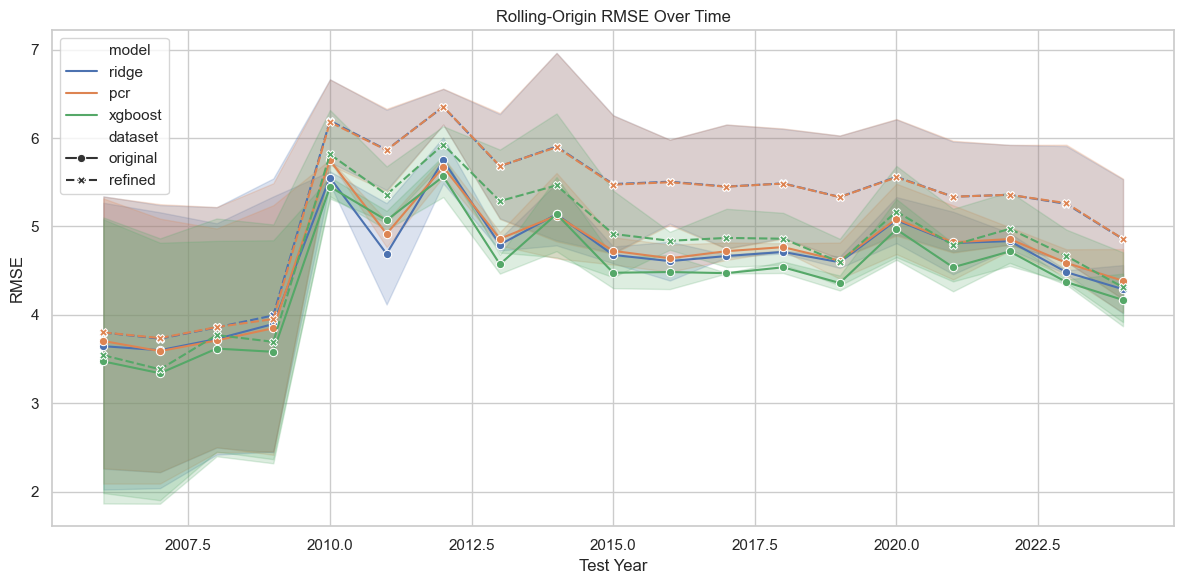

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=rolling_results,
    x="test_year",
    y="rmse",
    hue="model",
    style="dataset",
    markers=True
)
plt.title("Rolling-Origin RMSE Over Time")
plt.xlabel("Test Year")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

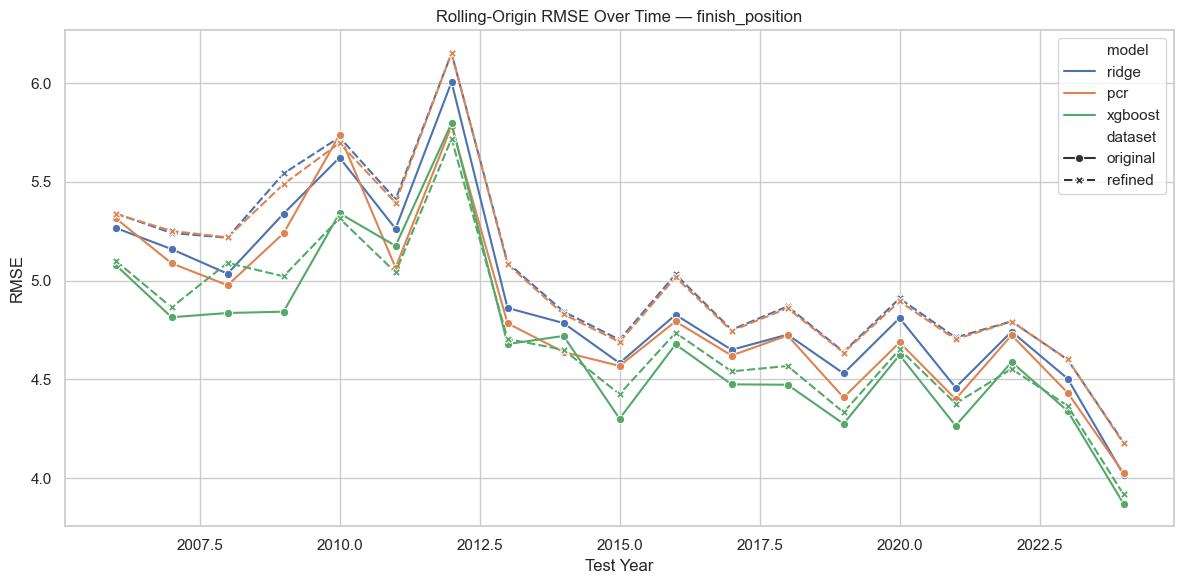

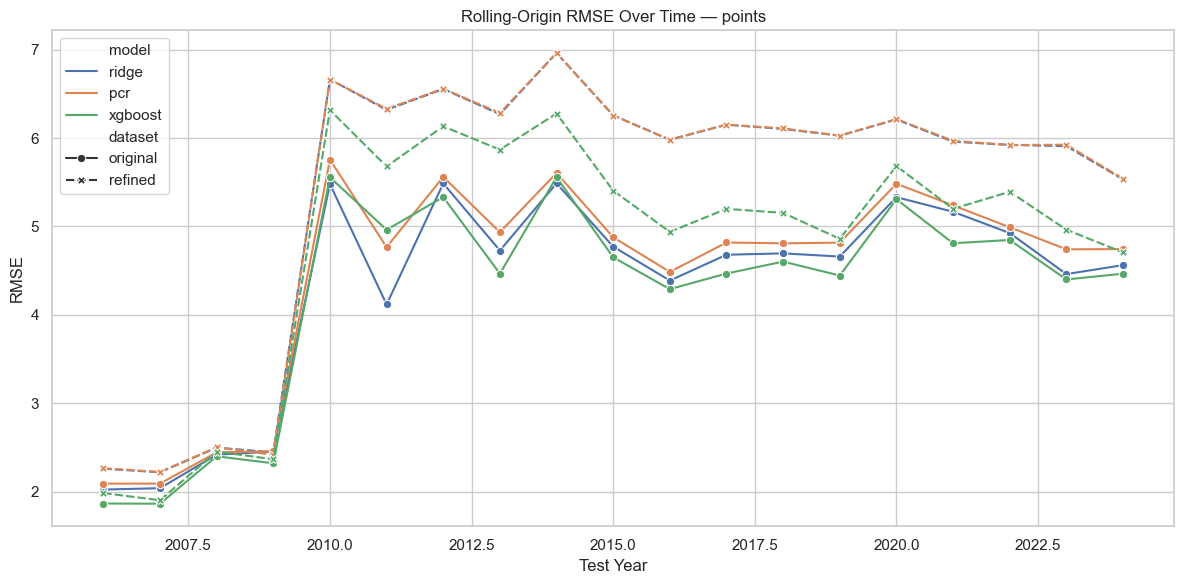

In [24]:
for target_name in TARGET_SPECS:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=rolling_results[rolling_results["target"] == target_name],
        x="test_year",
        y="rmse",
        hue="model",
        style="dataset",
        markers=True
    )
    plt.title(f"Rolling-Origin RMSE Over Time — {target_name}")
    plt.xlabel("Test Year")
    plt.ylabel("RMSE")
    plt.tight_layout()
    plt.show()

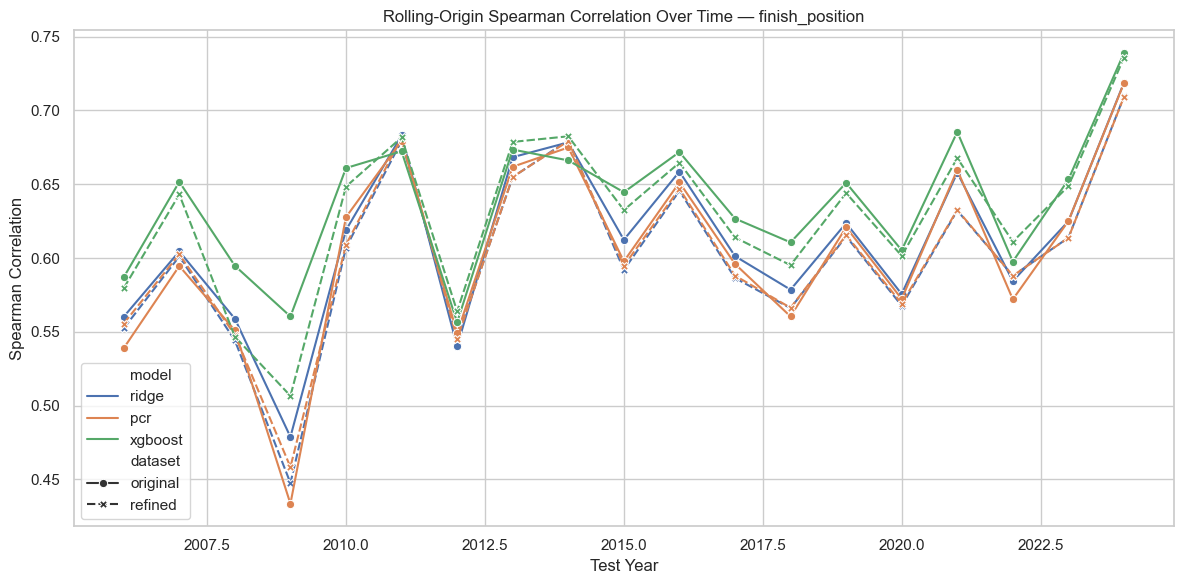

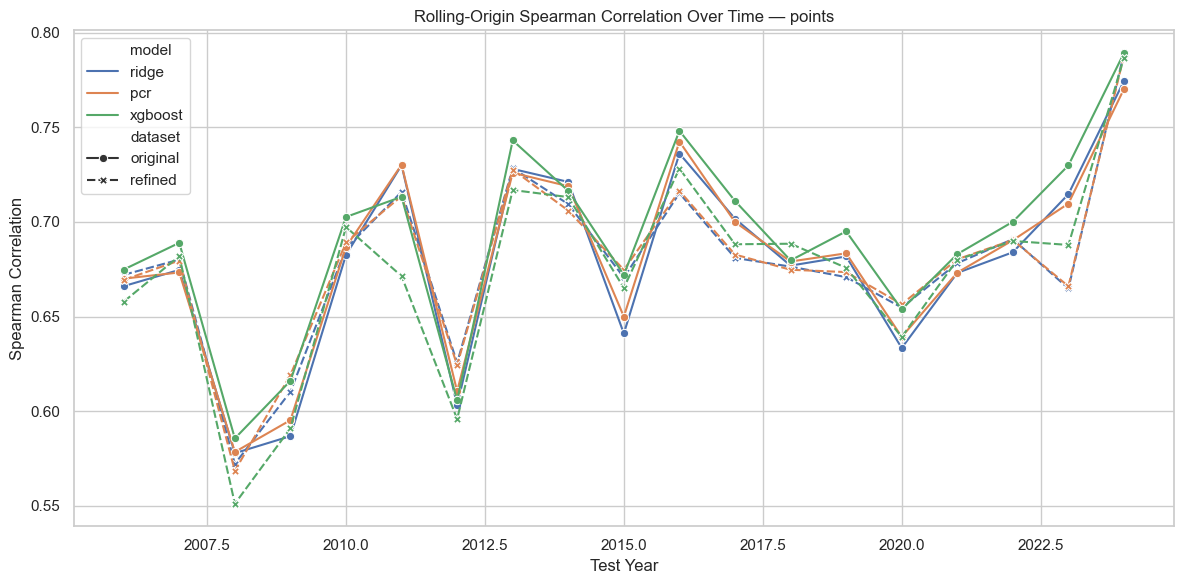

In [25]:
for target_name in TARGET_SPECS:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=rolling_results[rolling_results["target"] == target_name],
        x="test_year",
        y="spearman",
        hue="model",
        style="dataset",
        markers=True
    )
    plt.title(f"Rolling-Origin Spearman Correlation Over Time — {target_name}")
    plt.xlabel("Test Year")
    plt.ylabel("Spearman Correlation")
    plt.tight_layout()
    plt.show()

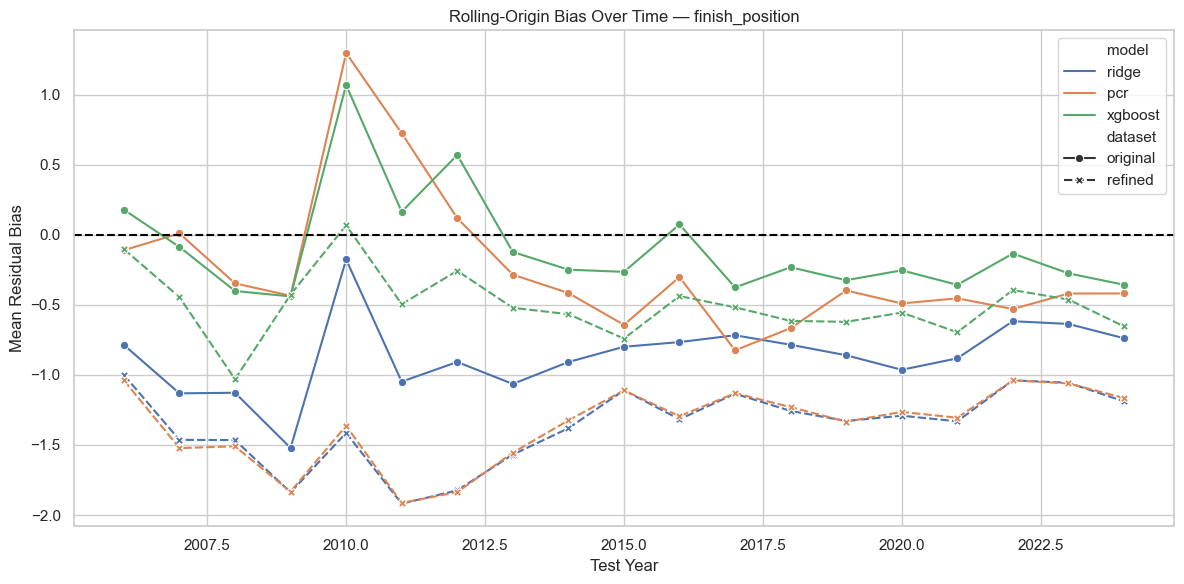

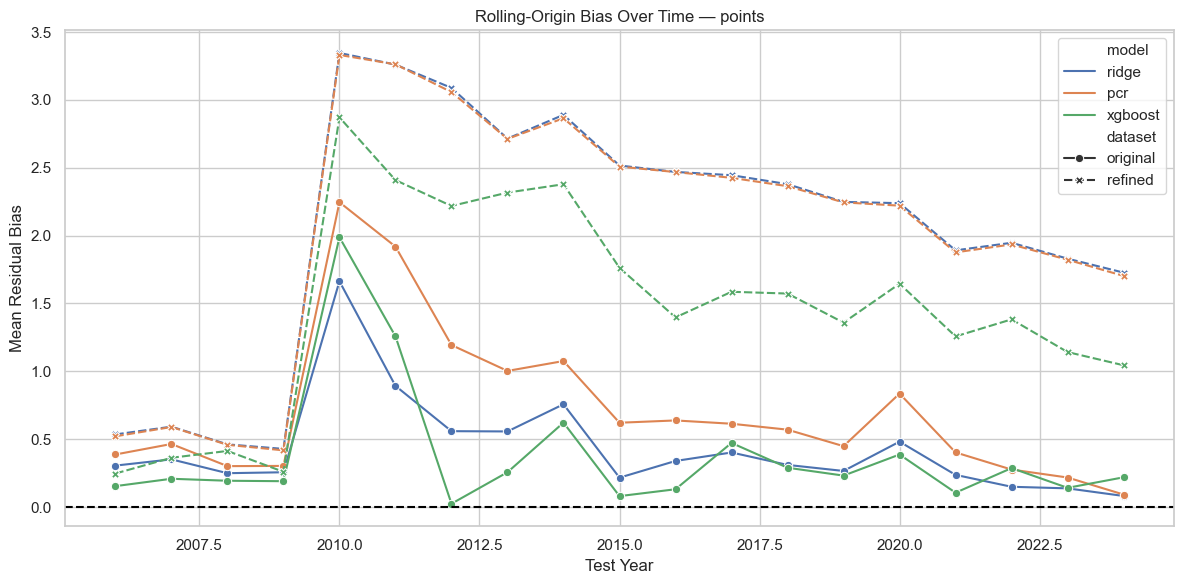

In [26]:
for target_name in TARGET_SPECS:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=rolling_results[rolling_results["target"] == target_name],
        x="test_year",
        y="bias",
        hue="model",
        style="dataset",
        markers=True
    )
    plt.axhline(0, linestyle="--", color="black")
    plt.title(f"Rolling-Origin Bias Over Time — {target_name}")
    plt.xlabel("Test Year")
    plt.ylabel("Mean Residual Bias")
    plt.tight_layout()
    plt.show()

## Rolling-Origin Validation Takeaways

Rolling-origin validation shows whether model quality is stable when evaluated in a realistic forecasting setup.

This matters because Formula 1 is not a static system:
- competitive hierarchies shift over time
- scoring dynamics evolve
- feature relationships may drift across eras

If a model performs well only on one train/test split but breaks down across rolling temporal windows, its apparent quality is overstated.

This section helps distinguish:
- models that are genuinely stable
- from models that perform well only under favorable split choices

Classical metrics assume:
correct model specification
linearity
homoskedastic errors
independence

Cross-validation:
makes fewer assumptions
directly estimates out-of-sample error
captures real-world instability

## Sensitivity to Train/Test Windows

While rolling-origin validation evaluates temporal stability across expanding windows, it is also important to understand how sensitive model performance is to the choice of train/test split.

This section evaluates how model performance changes as the split year varies.

If performance changes significantly across splits, conclusions drawn from a single train/test split may be unreliable.

In [27]:
window_rows = []

for split_year in range(2008, 2023):
    for target_name in TARGET_SPECS:
        for dataset_name, feature_set in {
            "original": original_features,
            "refined": refined_features
        }.items():

            model_df = df[[target_name, "year"] + feature_set].copy()
            model_df = model_df.dropna(subset=[target_name]).copy()

            train = model_df[model_df["year"] <= split_year].copy()
            test = model_df[model_df["year"] > split_year].copy()

            if train.empty or test.empty:
                continue

            X_train = train[feature_set]
            y_train = train[target_name]
            X_test = test[feature_set]
            y_test = test[target_name]

            for model_name, model in MODEL_REGISTRY[dataset_name].items():
                res = evaluate_regression(clone(model), X_train, y_train, X_test, y_test)

                window_rows.append({
                    "split_year": split_year,
                    "target": target_name,
                    "dataset": dataset_name,
                    "model": model_name,
                    **res
                })

window_results = pd.DataFrame(window_rows)
window_results.head()

,split_year,target,dataset,model,rmse,mae,medae,r2,explained_variance,bias,spearman
0,2008,finish_position,original,ridge,5.366685,4.106635,3.351871,0.244763,0.250105,-0.451353,0.625514
1,2008,finish_position,original,pcr,5.215963,3.794131,2.830725,0.286589,0.323818,1.191532,0.620142
2,2008,finish_position,original,xgboost,4.774201,3.672654,2.924771,0.402315,0.403195,0.183202,0.639867
3,2008,finish_position,refined,ridge,5.278583,4.358798,3.927768,0.269356,0.377353,-2.029414,0.628471
4,2008,finish_position,refined,pcr,5.244315,4.323292,3.893931,0.278812,0.382189,-1.985535,0.630867


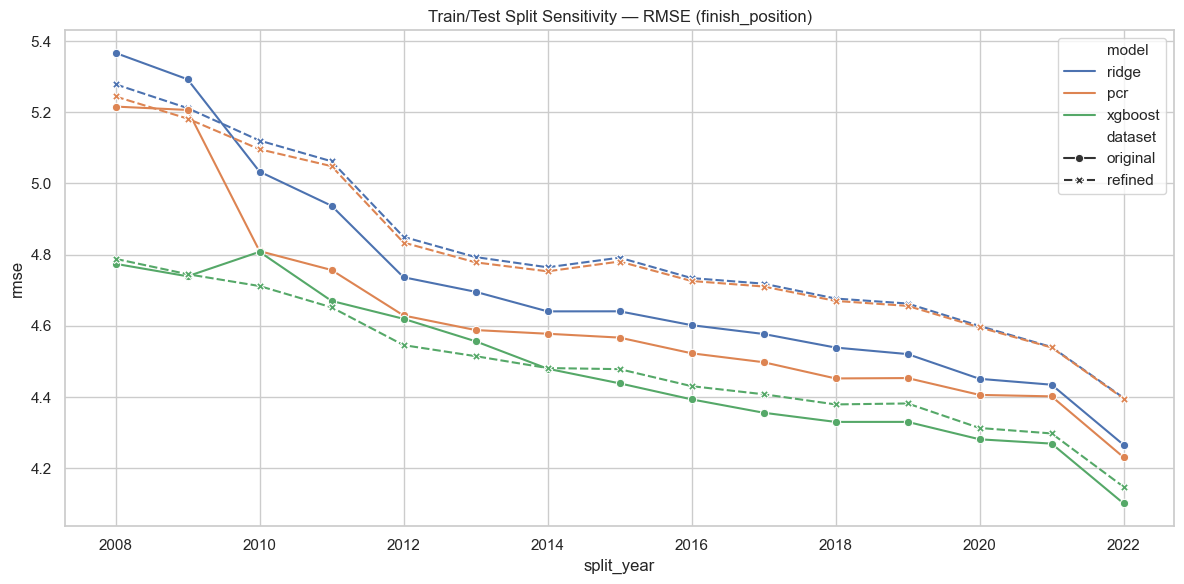

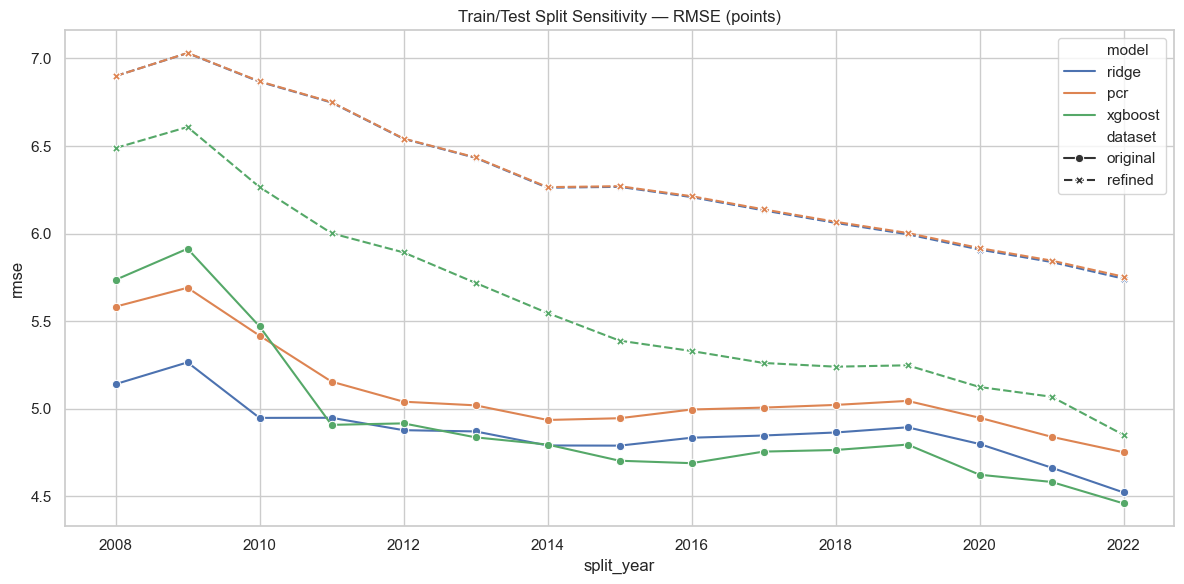

In [28]:
for target_name in TARGET_SPECS:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=window_results[window_results["target"] == target_name],
        x="split_year",
        y="rmse",
        hue="model",
        style="dataset",
        markers=True
    )
    plt.title(f"Train/Test Split Sensitivity — RMSE ({target_name})")
    plt.tight_layout()
    plt.show()

## Permutation Importance Stability

Permutation importance evaluates how much model performance degrades when each feature is randomly shuffled.

By repeating this process across bootstrap samples, we can assess whether feature importance rankings are stable or highly sensitive to sampling variation.

In [29]:
importance_rows = []

target_name = "finish_position"  # start with one

feature_set = refined_features
model = ridge_pipeline_refined

model_df = df[[target_name, "year"] + feature_set].dropna(subset=[target_name]).copy()

train = model_df[model_df["year"] <= 2021]
test = model_df[model_df["year"] > 2021]

X_train = train[feature_set]
y_train = train[target_name]
X_test = test[feature_set]
y_test = test[target_name]

for seed in range(30):
    boot_idx = np.random.default_rng(seed).choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.reset_index(drop=True).iloc[boot_idx]
    y_boot = y_train.reset_index(drop=True).iloc[boot_idx]

    m = clone(model)
    m.fit(X_boot, y_boot)

    perm = permutation_importance(
        m,
        X_test,
        y_test,
        n_repeats=5,
        random_state=seed,
        scoring="neg_root_mean_squared_error"
    )

    for f, imp in zip(feature_set, -perm.importances_mean):
        importance_rows.append({
            "seed": seed,
            "feature": f,
            "importance": imp
        })

importance_df = pd.DataFrame(importance_rows)

In [44]:
importance_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():
        for model_name, model in MODEL_REGISTRY[dataset_name].items():

            model_df = df[[target_name, "year"] + feature_set].copy()
            model_df = model_df.dropna().copy()

            train = model_df[model_df["year"] <= 2021].copy()
            test = model_df[model_df["year"] > 2021].copy()

            if train.empty or test.empty:
                continue

            X_train = train[feature_set]
            y_train = train[target_name]
            X_test = test[feature_set]
            y_test = test[target_name]

            for seed in range(20):
                rng = np.random.default_rng(seed)
                boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)

                X_boot = X_train.reset_index(drop=True).iloc[boot_idx]
                y_boot = y_train.reset_index(drop=True).iloc[boot_idx]

                fitted_model = clone(model)
                fitted_model.fit(X_boot, y_boot)

                perm = permutation_importance(
                    fitted_model,
                    X_test,
                    y_test,
                    n_repeats=5,
                    random_state=seed,
                    scoring="neg_root_mean_squared_error"
                )

                for f, imp_mean, imp_std in zip(
                    feature_set,
                    perm.importances_mean,
                    perm.importances_std
                ):
                    importance_rows.append({
                        "target": target_name,
                        "dataset": dataset_name,
                        "model": model_name,
                        "seed": seed,
                        "feature": f,
                        "importance_mean": imp_mean,
                        "importance_std": imp_std
                    })

importance_stability = pd.DataFrame(importance_rows)
importance_stability.head()

,target,dataset,model,seed,feature,importance_mean,importance_std
0,finish_position,original,ridge,0,grid_clean,0.074323,0.007275
1,finish_position,original,ridge,0,qualifying_position,0.578313,0.033136
2,finish_position,original,ridge,0,driver_avg_finish_last5,0.050345,0.002261
3,finish_position,original,ridge,0,driver_points_last5,0.054051,0.003812
4,finish_position,original,ridge,0,driver_dnf_rate_last5,0.000032,0.000160


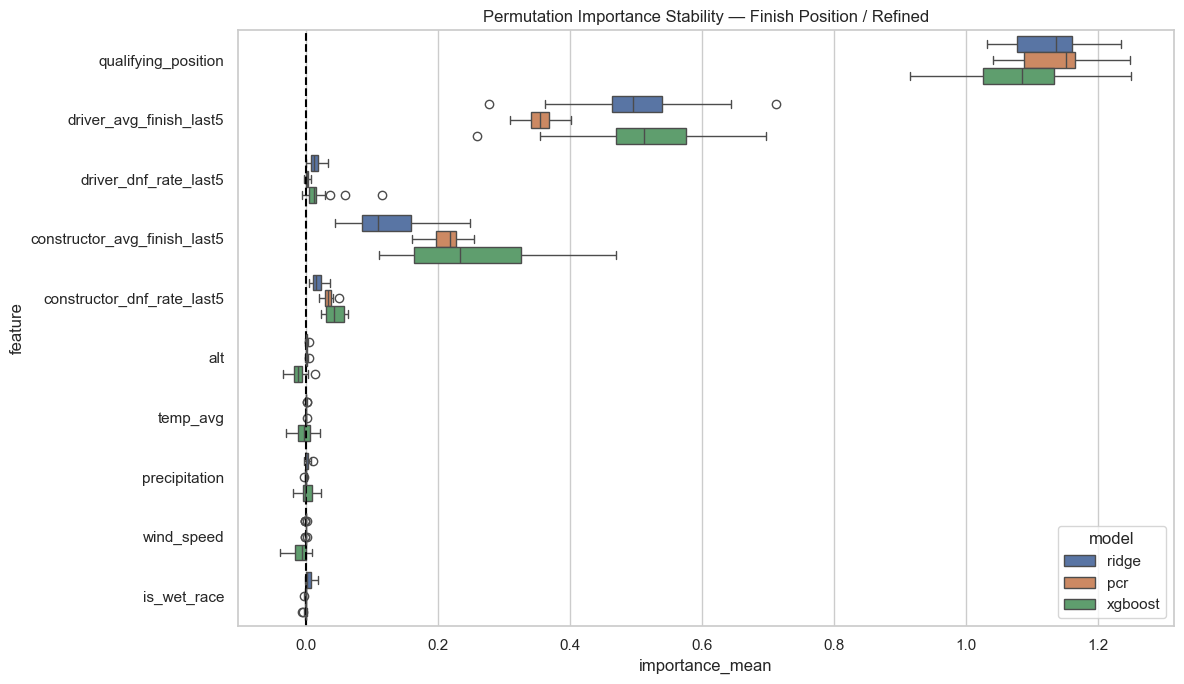

In [45]:
plot_df = importance_stability[
    (importance_stability["target"] == "finish_position") &
    (importance_stability["dataset"] == "refined")
].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(data=plot_df, x="importance_mean", y="feature", hue="model")
plt.axvline(0, linestyle="--", color="black")
plt.title("Permutation Importance Stability — Finish Position / Refined")
plt.tight_layout()
plt.show()

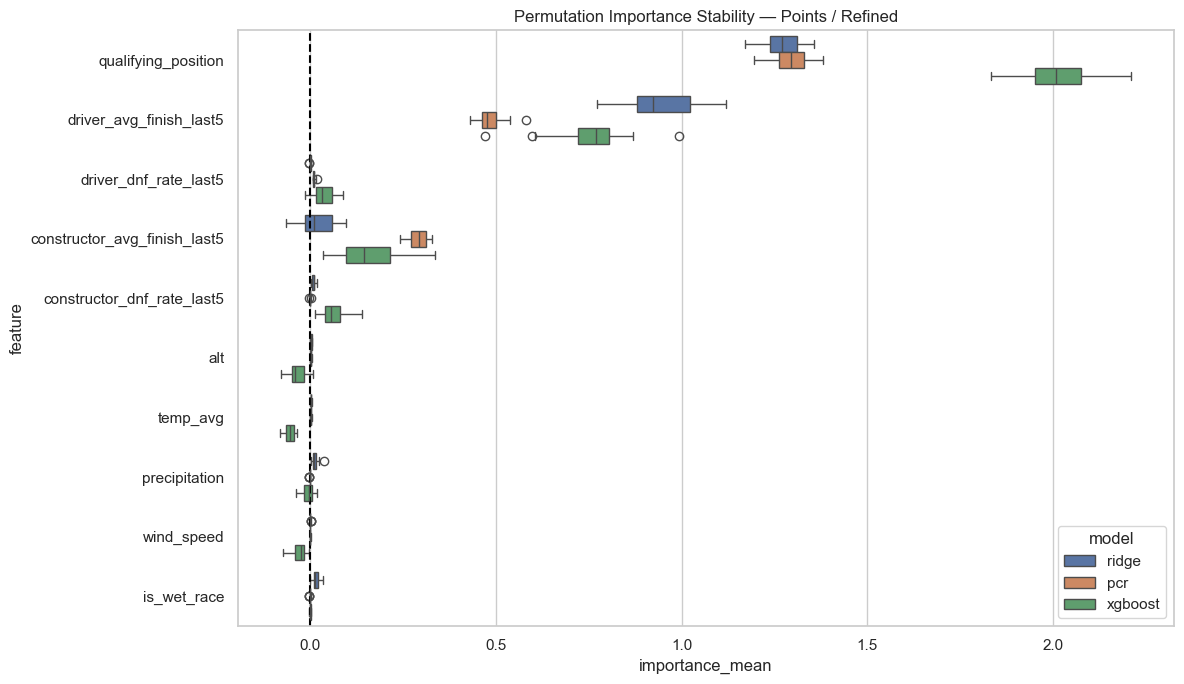

In [47]:
plot_df = importance_stability[
    (importance_stability["target"] == "points") &
    (importance_stability["dataset"] == "refined")
].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(data=plot_df, x="importance_mean", y="feature", hue="model")
plt.axvline(0, linestyle="--", color="black")
plt.title("Permutation Importance Stability — Points / Refined")
plt.tight_layout()
plt.show()

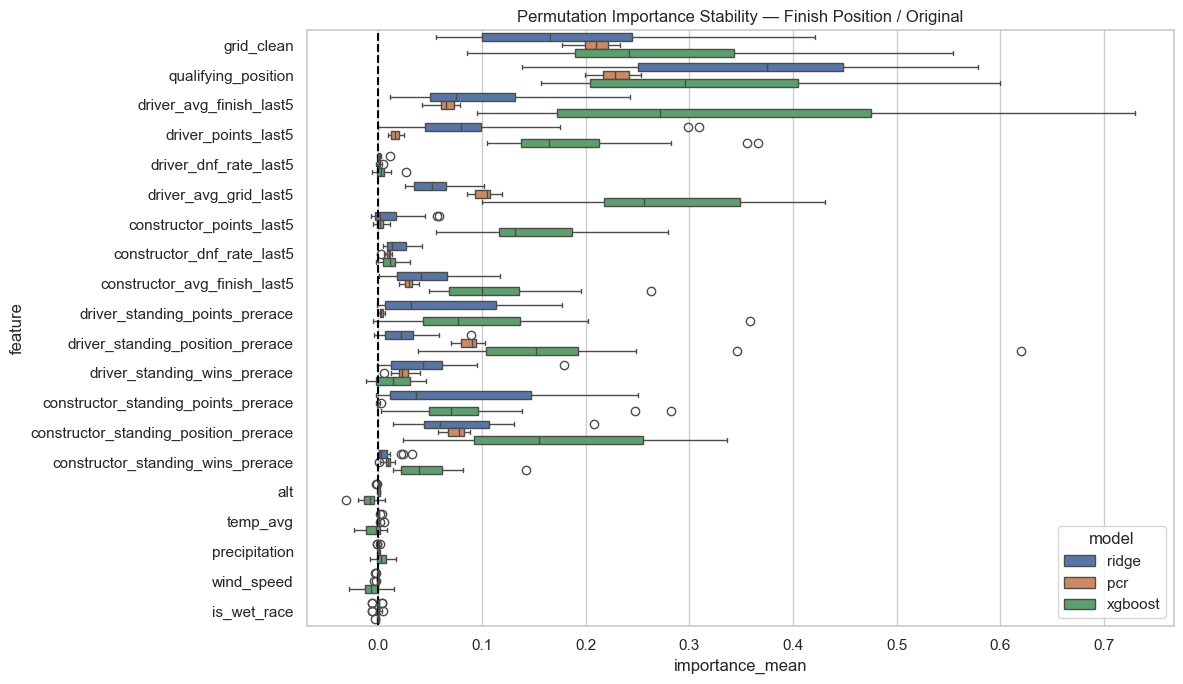

In [48]:
plot_df = importance_stability[
    (importance_stability["target"] == "finish_position") &
    (importance_stability["dataset"] == "original")
].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(data=plot_df, x="importance_mean", y="feature", hue="model")
plt.axvline(0, linestyle="--", color="black")
plt.title("Permutation Importance Stability — Finish Position / Original")
plt.tight_layout()
plt.show()

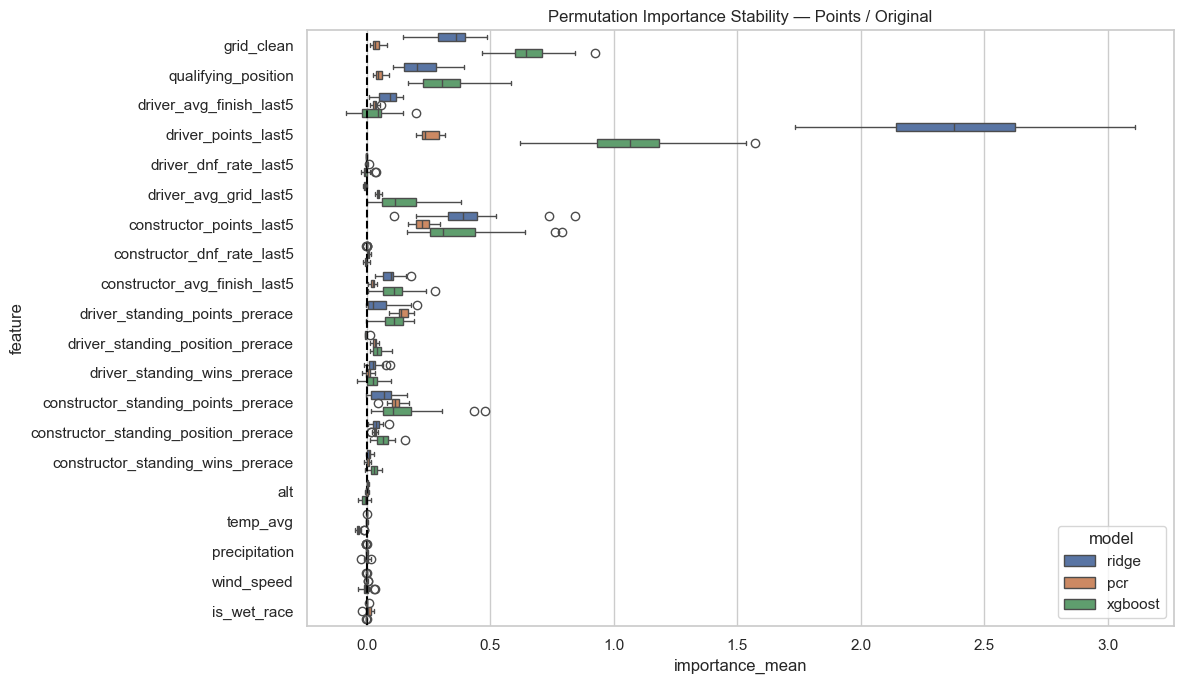

In [49]:
plot_df = importance_stability[
    (importance_stability["target"] == "points") &
    (importance_stability["dataset"] == "original")
].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(data=plot_df, x="importance_mean", y="feature", hue="model")
plt.axvline(0, linestyle="--", color="black")
plt.title("Permutation Importance Stability — Points / Original")
plt.tight_layout()
plt.show()

## Feature Importance Stability

Evaluate whether importance rankings remain consistent across bootstrap or rolling samples.

In [31]:
importance_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name, "year"] + feature_set].copy()
        for col in model_df.columns:
            model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

        model_df = model_df.dropna(subset=[target_name]).copy()

        train = model_df[model_df["year"] <= 2021].copy()
        test = model_df[model_df["year"] > 2021].copy()

        if train.empty or test.empty:
            continue

        X_train = train[feature_set]
        y_train = train[target_name]
        X_test = test[feature_set]
        y_test = test[target_name]

        for model_name, model in MODEL_REGISTRY[dataset_name].items():
            for seed in range(20):
                rng = np.random.default_rng(seed)
                boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)

                X_boot = X_train.reset_index(drop=True).iloc[boot_idx]
                y_boot = y_train.reset_index(drop=True).iloc[boot_idx]

                fitted_model = clone(model)
                fitted_model.fit(X_boot, y_boot)

                perm = permutation_importance(
                    fitted_model,
                    X_test,
                    y_test,
                    n_repeats=5,
                    random_state=seed,
                    scoring="neg_root_mean_squared_error"
                )

                for f, imp_mean, imp_std in zip(
                    feature_set,
                    -perm.importances_mean,
                    perm.importances_std
                ):
                    importance_rows.append({
                        "target": target_name,
                        "dataset": dataset_name,
                        "model": model_name,
                        "seed": seed,
                        "feature": f,
                        "importance_mean": imp_mean,
                        "importance_std": imp_std
                    })

importance_stability = pd.DataFrame(importance_rows)
importance_stability.head()

,target,dataset,model,seed,feature,importance_mean,importance_std
0,finish_position,original,ridge,0,grid_clean,-0.110776,0.017219
1,finish_position,original,ridge,0,qualifying_position,-0.063412,0.007998
2,finish_position,original,ridge,0,driver_avg_finish_last5,-0.105269,0.029150
3,finish_position,original,ridge,0,driver_points_last5,0.020877,0.005571
4,finish_position,original,ridge,0,driver_dnf_rate_last5,-0.033707,0.005552


In [32]:
importance_summary = (
    importance_stability
    .groupby(["target", "dataset", "model", "feature"], as_index=False)
    .agg(
        importance_mean=("importance_mean", "mean"),
        importance_std=("importance_mean", "std"),
        median_importance=("importance_mean", "median")
    )
    .sort_values(["target", "dataset", "model", "importance_mean"], ascending=[True, True, True, False])
)

importance_summary.head(20)

,target,dataset,model,feature,importance_mean,importance_std,median_importance
2,finish_position,original,pcr,constructor_dnf_rate_last5,0.027407,0.003503,0.026939
9,finish_position,original,pcr,driver_dnf_rate_last5,0.009523,0.002250,0.009900
11,finish_position,original,pcr,driver_standing_points_prerace,0.002508,0.006375,0.004528
4,finish_position,original,pcr,constructor_standing_points_prerace,0.001586,0.004825,0.002029
0,finish_position,original,pcr,alt,0.001019,0.001217,0.000783
19,finish_position,original,pcr,wind_speed,-0.000099,0.000492,-0.000064
18,finish_position,original,pcr,temp_avg,-0.000103,0.000804,-0.000050
16,finish_position,original,pcr,precipitation,-0.000245,0.000721,-0.000175
15,finish_position,original,pcr,is_wet_race,-0.001998,0.002634,-0.001679
10,finish_position,original,pcr,driver_points_last5,-0.004738,0.002992,-0.005029


In [35]:
importance_stability["abs_importance"] = importance_stability["importance_mean"].abs()

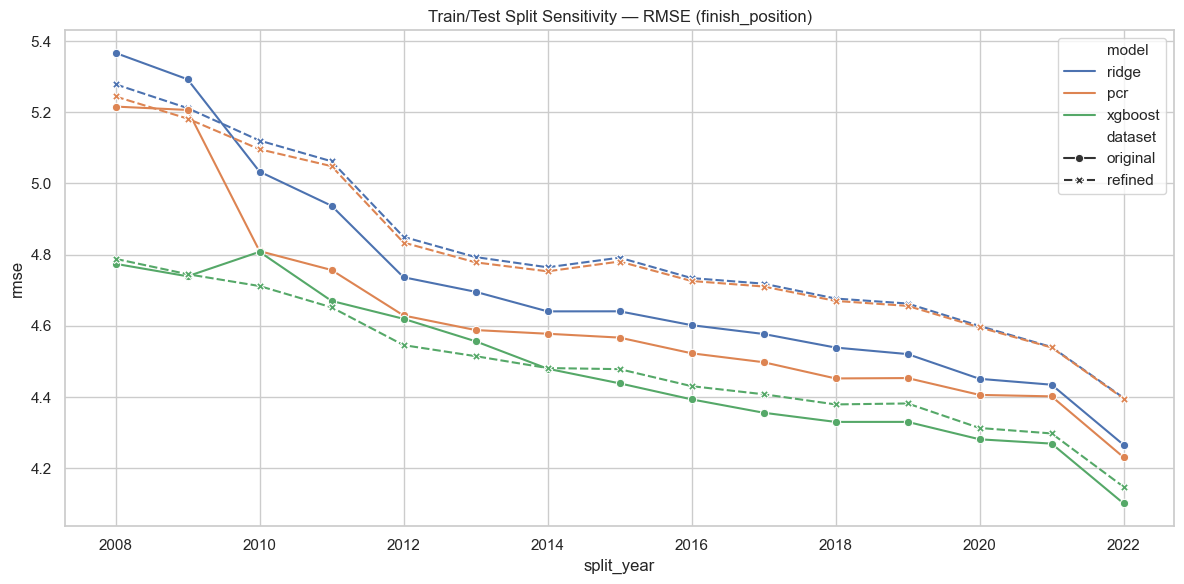

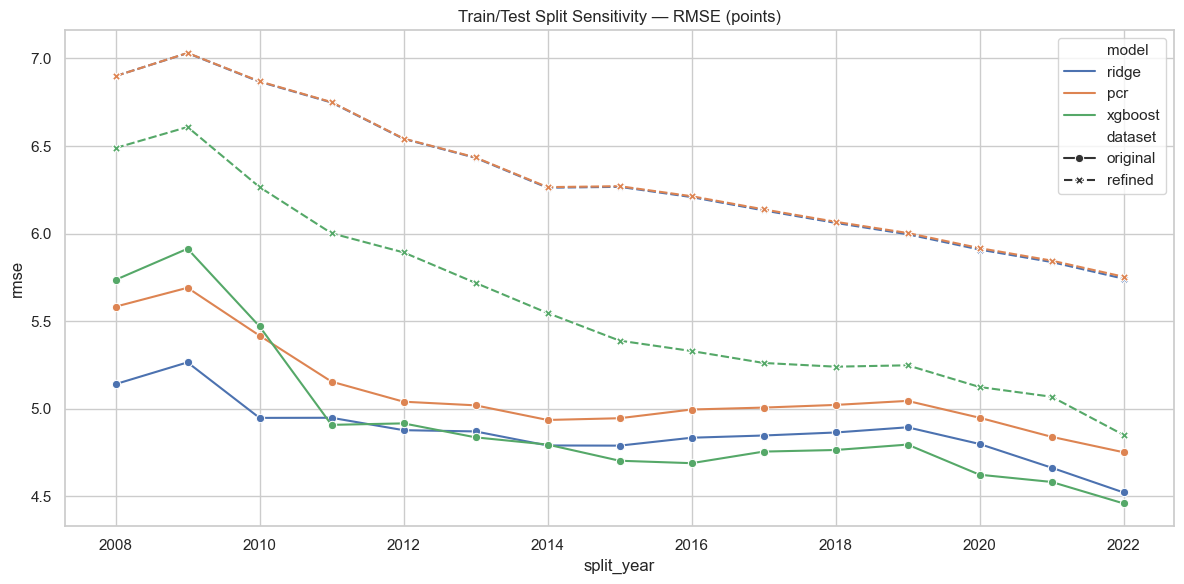

In [36]:
for target_name in TARGET_SPECS:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=window_results[window_results["target"] == target_name],
        x="split_year",
        y="rmse",
        hue="model",
        style="dataset",
        markers=True
    )
    plt.title(f"Train/Test Split Sensitivity — RMSE ({target_name})")
    plt.tight_layout()
    plt.show()

## Interpreting Permutation Importance Across Models

Permutation importance is computed by shuffling the original input features and measuring how much predictive performance degrades.

For ridge and XGBoost, this maps directly to the feature set used by the model.

For PCR, the interpretation is slightly different: the model is estimated on principal components, but the importance values still reflect how much each original input feature matters to the full PCA-plus-regression pipeline.

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
import numpy as np
import pandas as pd

results_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name, "year"] + feature_set].copy()

        # numeric + clean
        for col in model_df.columns:
            model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

        model_df = model_df.dropna().copy()

        # time split (consistent with your notebook)
        train = model_df[model_df["year"] <= 2021]
        test = model_df[model_df["year"] > 2021]

        X_train = train[feature_set]
        y_train = train[target_name]
        X_test = test[feature_set]
        y_test = test[target_name]

        for model_name, model in MODEL_REGISTRY[dataset_name].items():

            m = clone(model)
            m.fit(X_train, y_train)
            preds = m.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, preds))
            r2 = r2_score(y_test, preds)

            results_rows.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                "rmse": rmse,
                "r2": r2
            })

results_df = pd.DataFrame(results_rows)
results_df.head()

,target,dataset,model,rmse,r2
0,finish_position,original,ridge,4.249857,0.470250
1,finish_position,original,pcr,4.282663,0.462040
2,finish_position,original,xgboost,4.396162,0.433148
3,finish_position,refined,ridge,4.228889,0.467889
4,finish_position,refined,pcr,4.232978,0.466859


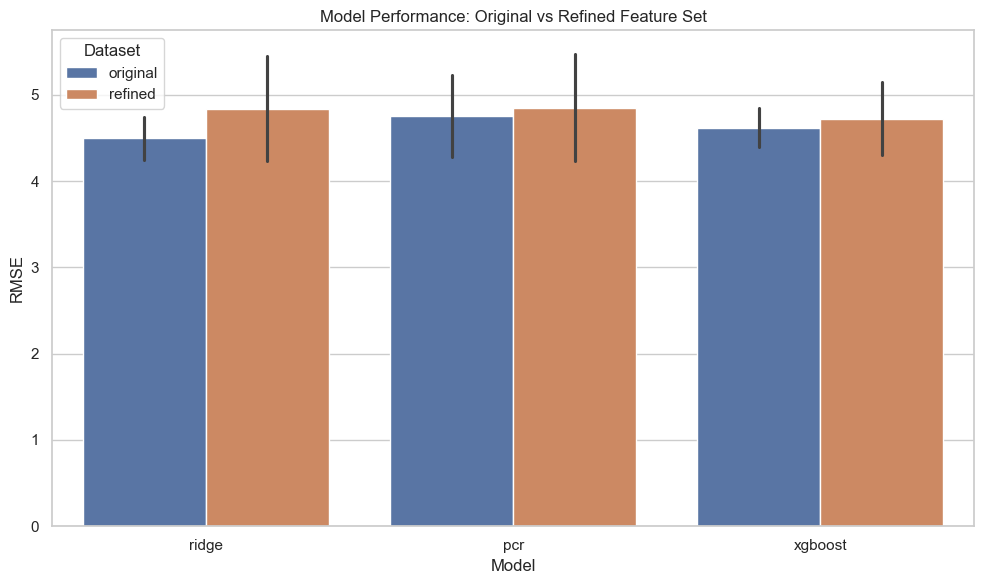

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="model",
    y="rmse",
    hue="dataset"
)

plt.title("Model Performance: Original vs Refined Feature Set")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

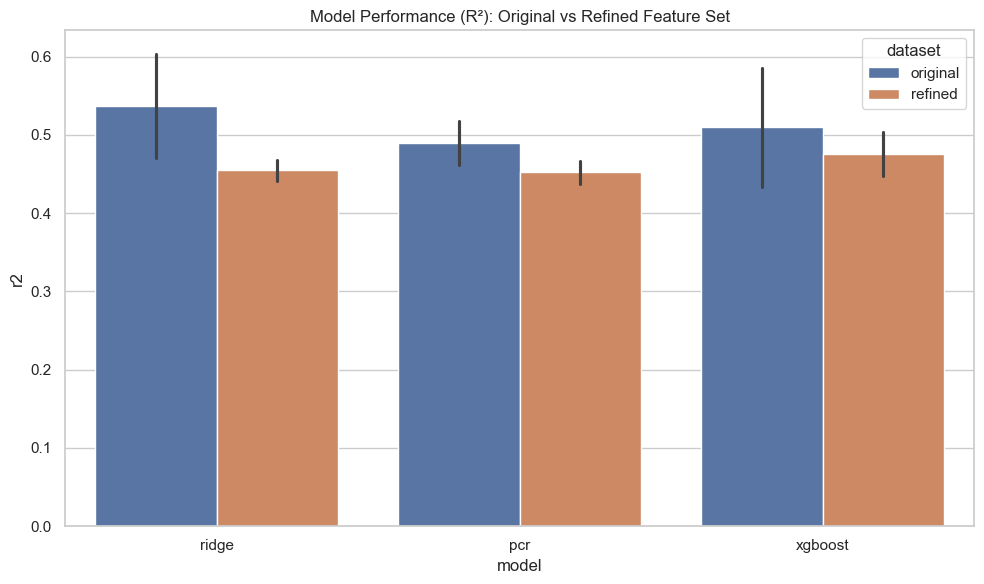

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="model",
    y="r2",
    hue="dataset"
)

plt.title("Model Performance (R²): Original vs Refined Feature Set")
plt.tight_layout()
plt.show()

In [57]:
from sklearn.model_selection import KFold

cv_rows = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name] + feature_set].dropna().copy()

        X = model_df[feature_set]
        y = model_df[target_name]

        for model_name, model in MODEL_REGISTRY[dataset_name].items():

            for fold, (train_idx, test_idx) in enumerate(kf.split(X)):

                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                m = clone(model)
                m.fit(X_train, y_train)
                preds = m.predict(X_test)

                rmse = np.sqrt(mean_squared_error(y_test, preds))

                cv_rows.append({
                    "target": target_name,
                    "dataset": dataset_name,
                    "model": model_name,
                    "fold": fold,
                    "rmse": rmse
                })

cv_df = pd.DataFrame(cv_rows)

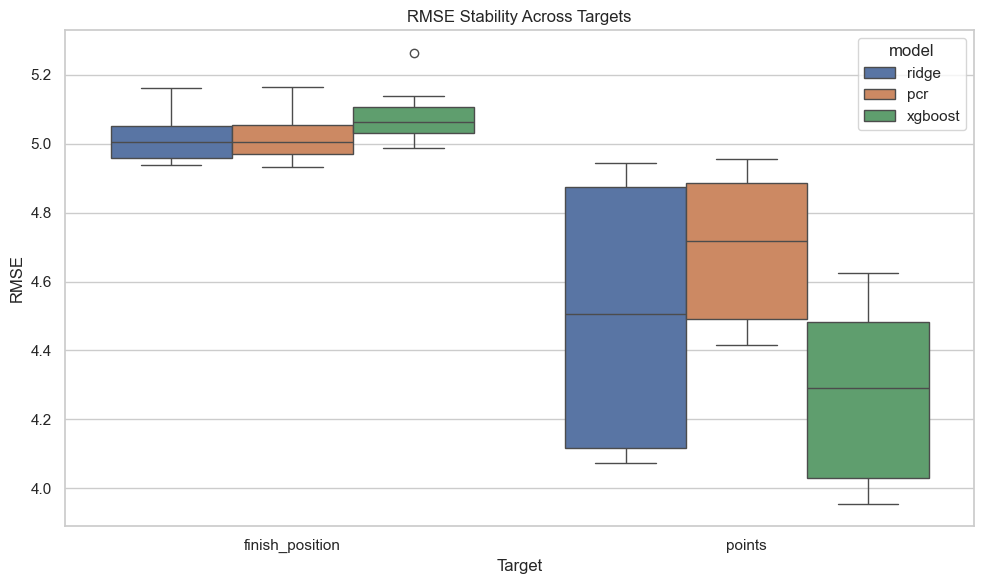

In [58]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cv_df,
    x="target",
    y="rmse",
    hue="model"
)

plt.title("RMSE Stability Across Targets")
plt.ylabel("RMSE")
plt.xlabel("Target")
plt.tight_layout()
plt.show()

In [59]:
residual_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name, "year"] + feature_set].dropna().copy()

        train = model_df[model_df["year"] <= 2021]
        test = model_df[model_df["year"] > 2021]

        X_train = train[feature_set]
        y_train = train[target_name]
        X_test = test[feature_set]
        y_test = test[target_name]

        for model_name, model in MODEL_REGISTRY[dataset_name].items():

            m = clone(model)
            m.fit(X_train, y_train)
            preds = m.predict(X_test)

            residuals = y_test - preds

            for r in residuals:
                residual_rows.append({
                    "target": target_name,
                    "dataset": dataset_name,
                    "model": model_name,
                    "residual": r
                })

residual_df = pd.DataFrame(residual_rows)

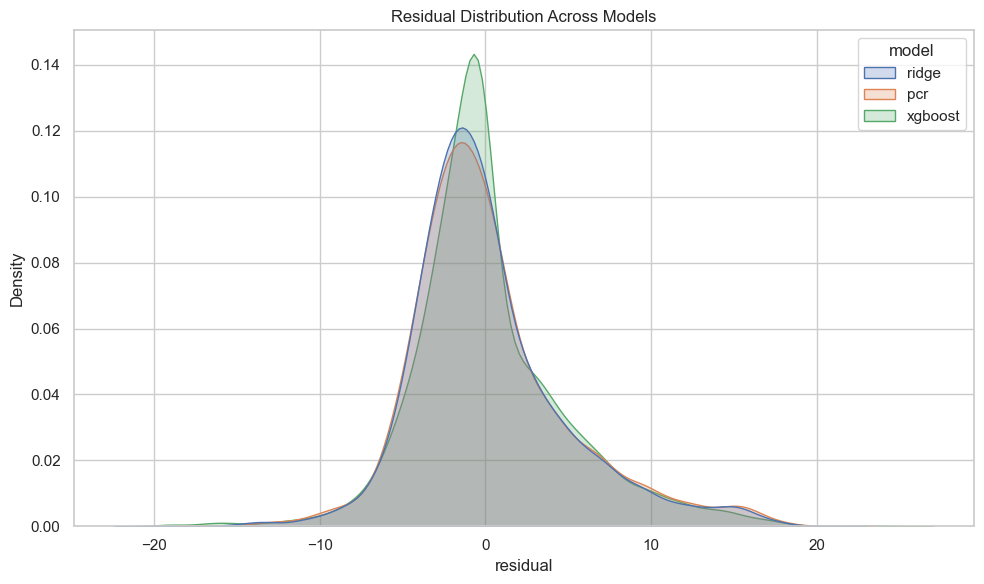

In [60]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=residual_df,
    x="residual",
    hue="model",
    fill=True,
    common_norm=False
)

plt.title("Residual Distribution Across Models")
plt.tight_layout()
plt.show()

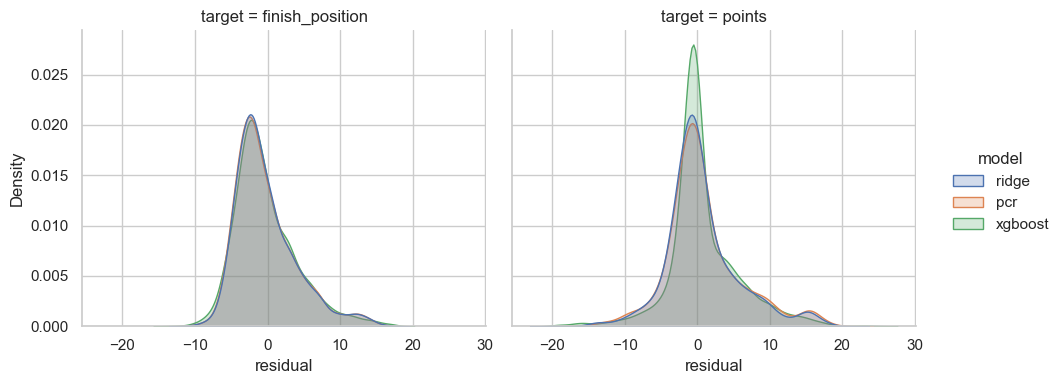

In [61]:
sns.displot(
    data=residual_df,
    x="residual",
    col="target",
    hue="model",
    kind="kde",
    fill=True,
    height=4,
    aspect=1.2
)

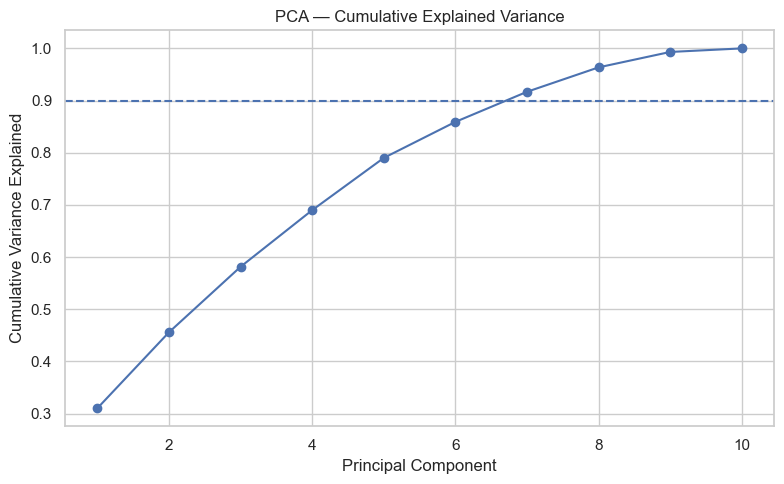

In [62]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_set = refined_features  # or original_features

model_df = df[feature_set].dropna().copy()

X_scaled = StandardScaler().fit_transform(model_df)

pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA — Cumulative Explained Variance")
plt.axhline(0.9, linestyle="--")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_summary,
    x="importance",
    y="feature",
    hue="model"
)

plt.title("Feature Importance Comparison Across Models")
plt.tight_layout()
plt.show()

In [64]:
importance_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():
        for model_name, model in MODEL_REGISTRY[dataset_name].items():

            model_df = df[[target_name, "year"] + feature_set].copy()

            for col in model_df.columns:
                model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

            model_df = model_df.dropna().copy()

            train = model_df[model_df["year"] <= 2021].copy()
            test = model_df[model_df["year"] > 2021].copy()

            if train.empty or test.empty:
                continue

            X_train = train[feature_set]
            y_train = train[target_name]
            X_test = test[feature_set]
            y_test = test[target_name]

            for seed in range(20):
                rng = np.random.default_rng(seed)
                boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)

                X_boot = X_train.reset_index(drop=True).iloc[boot_idx]
                y_boot = y_train.reset_index(drop=True).iloc[boot_idx]

                fitted_model = clone(model)
                fitted_model.fit(X_boot, y_boot)

                perm = permutation_importance(
                    fitted_model,
                    X_test,
                    y_test,
                    n_repeats=5,
                    random_state=seed,
                    scoring="neg_root_mean_squared_error"
                )

                for f, imp_mean, imp_std in zip(
                    feature_set,
                    perm.importances_mean,
                    perm.importances_std
                ):
                    importance_rows.append({
                        "target": target_name,
                        "dataset": dataset_name,
                        "model": model_name,
                        "seed": seed,
                        "feature": f,
                        "importance_mean": imp_mean,
                        "importance_std": imp_std
                    })

importance_stability = pd.DataFrame(importance_rows)
importance_stability.head()

,target,dataset,model,seed,feature,importance_mean,importance_std
0,finish_position,original,ridge,0,grid_clean,0.074323,0.007275
1,finish_position,original,ridge,0,qualifying_position,0.578313,0.033136
2,finish_position,original,ridge,0,driver_avg_finish_last5,0.050345,0.002261
3,finish_position,original,ridge,0,driver_points_last5,0.054051,0.003812
4,finish_position,original,ridge,0,driver_dnf_rate_last5,0.000032,0.000160


In [65]:
importance_stability.columns.tolist()

['target',
 'dataset',
 'model',
 'seed',
 'feature',
 'importance_mean',
 'importance_std']

In [66]:
importance_stability.shape
importance_stability[["target", "dataset", "model"]].drop_duplicates().sort_values(["target", "dataset", "model"])

,target,dataset,model
400,finish_position,original,pcr
0,finish_position,original,ridge
800,finish_position,original,xgboost
1400,finish_position,refined,pcr
1200,finish_position,refined,ridge
1600,finish_position,refined,xgboost
2200,points,original,pcr
1800,points,original,ridge
2600,points,original,xgboost
3200,points,refined,pcr


In [67]:
importance_summary = (
    importance_stability
    .groupby(["target", "dataset", "model", "feature"], as_index=False)
    .agg(
        avg_importance=("importance_mean", "mean"),
        sd_importance=("importance_mean", "std"),
        median_importance=("importance_mean", "median")
    )
)

In [68]:
importance_summary = importance_summary.sort_values(
    ["target", "dataset", "model", "avg_importance"],
    ascending=[True, True, True, False]
)

importance_summary.head(20)

,target,dataset,model,feature,avg_importance,sd_importance,median_importance
17,finish_position,original,pcr,qualifying_position,0.229429,0.016331,0.228546
14,finish_position,original,pcr,grid_clean,0.209742,0.015408,0.210079
8,finish_position,original,pcr,driver_avg_grid_last5,0.102654,0.009223,0.105072
12,finish_position,original,pcr,driver_standing_position_prerace,0.087696,0.010118,0.090158
5,finish_position,original,pcr,constructor_standing_position_prerace,0.074978,0.009337,0.077552
7,finish_position,original,pcr,driver_avg_finish_last5,0.065754,0.009197,0.065150
1,finish_position,original,pcr,constructor_avg_finish_last5,0.029083,0.004723,0.029427
13,finish_position,original,pcr,driver_standing_wins_prerace,0.023996,0.008689,0.023208
10,finish_position,original,pcr,driver_points_last5,0.016282,0.004632,0.016111
2,finish_position,original,pcr,constructor_dnf_rate_last5,0.009647,0.002762,0.010478


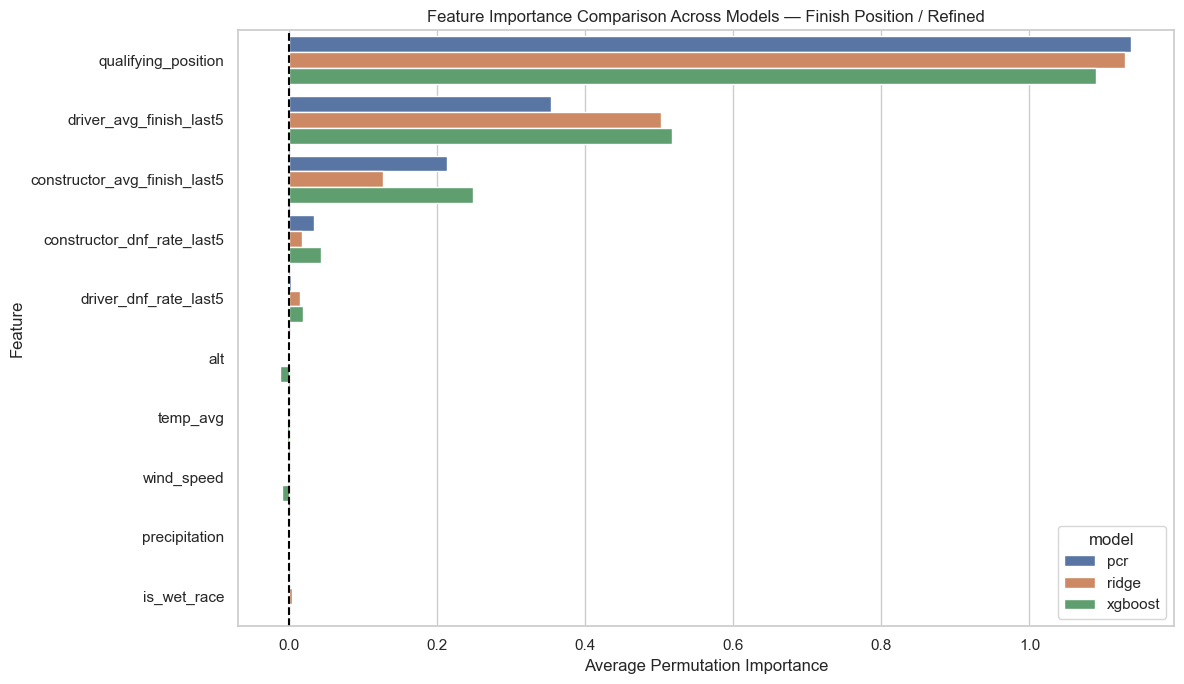

In [69]:
plot_df = importance_summary[
    (importance_summary["target"] == "finish_position") &
    (importance_summary["dataset"] == "refined")
].copy()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x="avg_importance",
    y="feature",
    hue="model"
)
plt.axvline(0, linestyle="--", color="black")
plt.title("Feature Importance Comparison Across Models — Finish Position / Refined")
plt.xlabel("Average Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

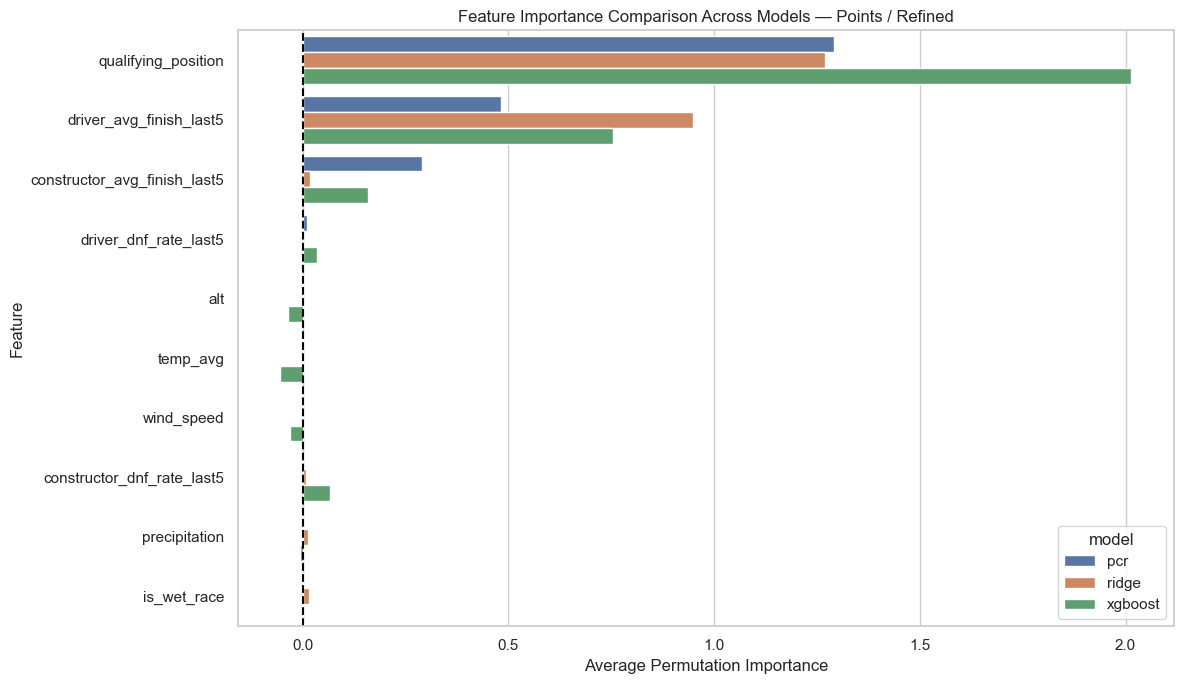

In [70]:
plot_df = importance_summary[
    (importance_summary["target"] == "points") &
    (importance_summary["dataset"] == "refined")
].copy()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x="avg_importance",
    y="feature",
    hue="model"
)
plt.axvline(0, linestyle="--", color="black")
plt.title("Feature Importance Comparison Across Models — Points / Refined")
plt.xlabel("Average Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

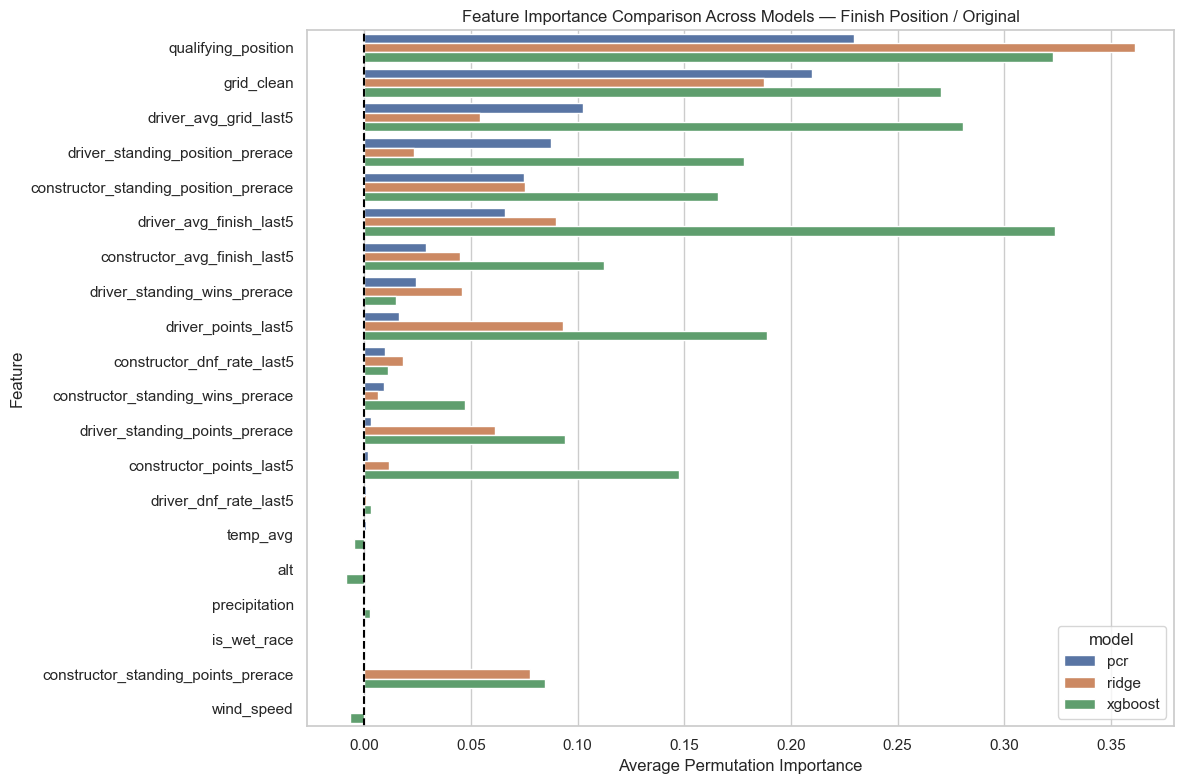

In [71]:
plot_df = importance_summary[
    (importance_summary["target"] == "finish_position") &
    (importance_summary["dataset"] == "original")
].copy()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_df,
    x="avg_importance",
    y="feature",
    hue="model"
)
plt.axvline(0, linestyle="--", color="black")
plt.title("Feature Importance Comparison Across Models — Finish Position / Original")
plt.xlabel("Average Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

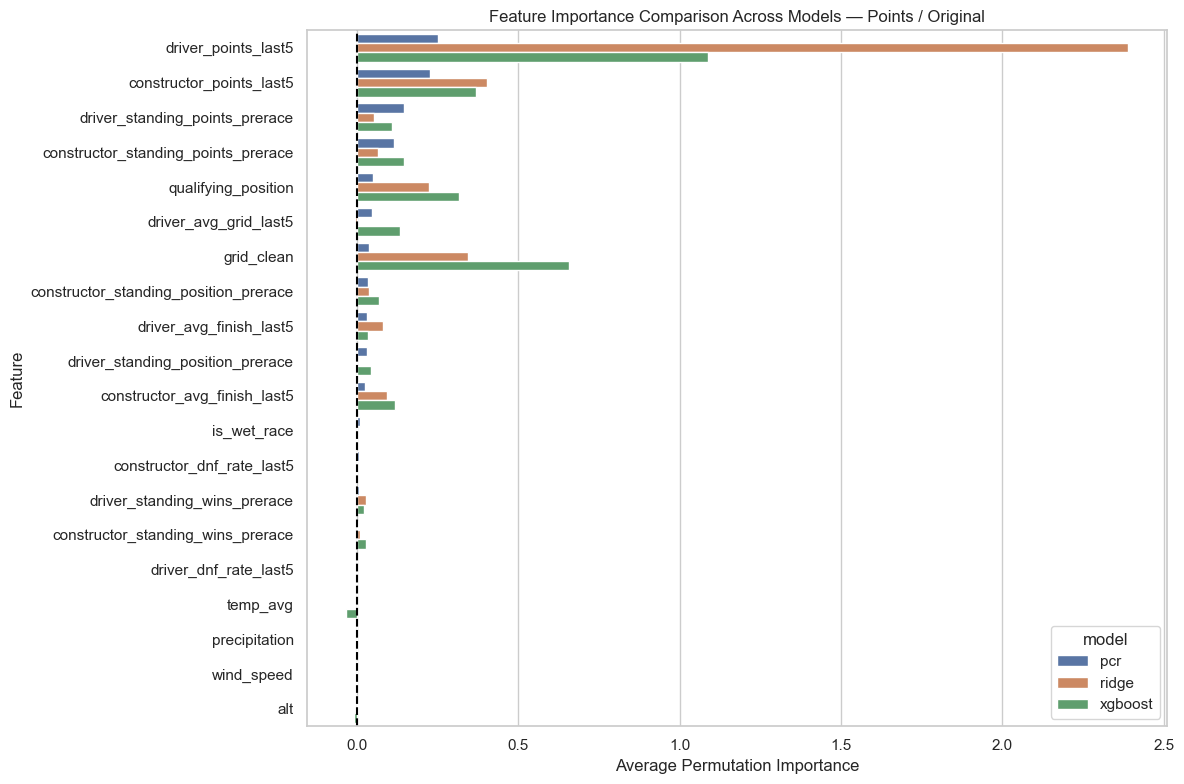

In [72]:
plot_df = importance_summary[
    (importance_summary["target"] == "points") &
    (importance_summary["dataset"] == "original")
].copy()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_df,
    x="avg_importance",
    y="feature",
    hue="model"
)
plt.axvline(0, linestyle="--", color="black")
plt.title("Feature Importance Comparison Across Models — Points / Original")
plt.xlabel("Average Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

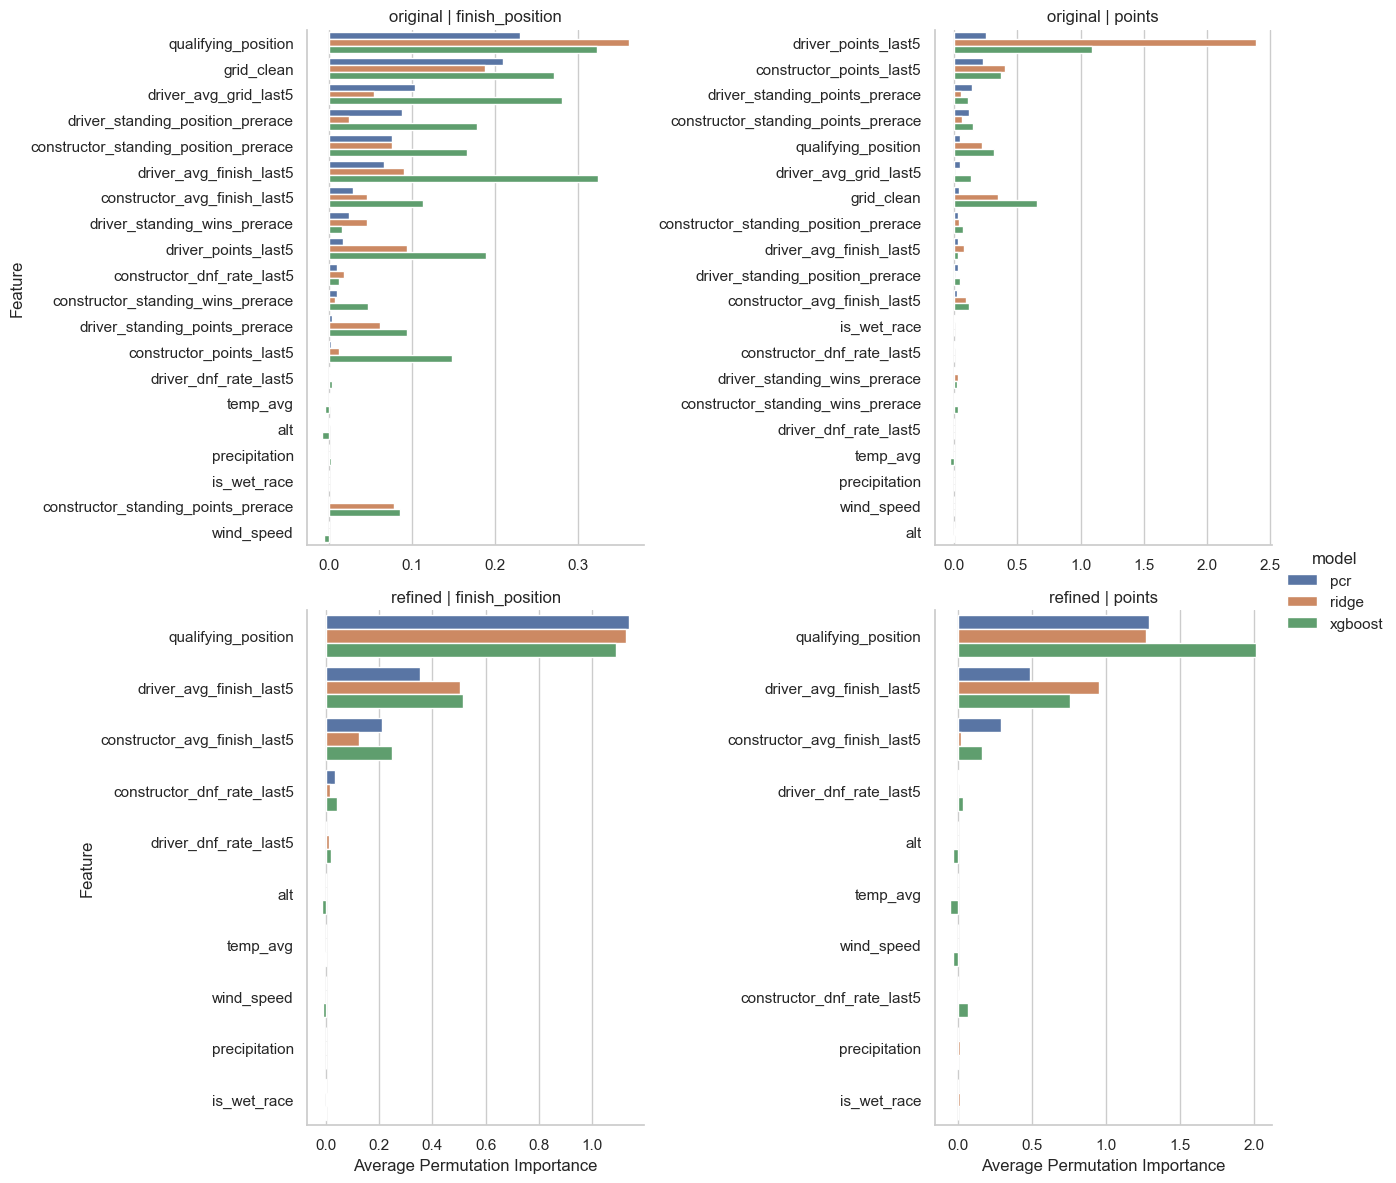

In [73]:
g = sns.catplot(
    data=importance_summary,
    x="avg_importance",
    y="feature",
    hue="model",
    col="target",
    row="dataset",
    kind="bar",
    height=6,
    aspect=1.1,
    sharex=False,
    sharey=False
)

g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("Average Permutation Importance", "Feature")
plt.show()

## Classical Model Selection Criteria vs Cross-Validation

In addition to resampling-based validation, classical statistical criteria can be used to evaluate model quality:

- AIC (Akaike Information Criterion)
- BIC (Bayesian Information Criterion)
- Adjusted R²
- Mallows’ Cp

These methods rely on assumptions about:
- model linearity
- error distribution
- correct model specification

Comparing them with cross-validation highlights the tradeoffs between:
- theoretical model selection criteria
- empirical estimation of test error

Because AIC, BIC, adjusted R², and Mallows’ Cp are being computed using ordinary least squares rather than the imputation pipelines used elsewhere, this section is estimated on complete-case samples only.

In [37]:
def regression_diagnostics(X, y, model):
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    valid_idx = X.notna().all(axis=1) & y.notna()
    X = X.loc[valid_idx].copy()
    y = y.loc[valid_idx].copy()

    model.fit(X, y)
    preds = model.predict(X)

    n = len(y)
    p = X.shape[1]

    residuals = y - preds
    rss = np.sum(residuals**2)
    mse = rss / (n - p - 1)

    r2 = r2_score(y, preds)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    aic = n * np.log(rss / n) + 2 * p
    bic = n * np.log(rss / n) + p * np.log(n)

    return {
        "n_obs": n,
        "n_features": p,
        "rss": rss,
        "mse": mse,
        "r2": r2,
        "adj_r2": adj_r2,
        "aic": aic,
        "bic": bic
    }

In [38]:
def mallows_cp(full_model, sub_model, X_full, y):
    X_full = X_full.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    valid_idx = X_full.notna().all(axis=1) & y.notna()
    X_full = X_full.loc[valid_idx].copy()
    y = y.loc[valid_idx].copy()

    full_model.fit(X_full, y)
    full_preds = full_model.predict(X_full)

    n = len(y)
    p = X_full.shape[1]

    sigma2 = np.sum((y - full_preds)**2) / (n - p - 1)

    sub_model.fit(X_full, y)
    sub_preds = sub_model.predict(X_full)

    rss = np.sum((y - sub_preds)**2)
    cp = rss / sigma2 - (n - 2 * p)

    return cp

In [50]:
from sklearn.base import clone
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

def model_diagnostics(X, y, model, model_name, full_model_rss=None, full_model_p=None):
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    valid_idx = X.notna().all(axis=1) & y.notna()
    X = X.loc[valid_idx].copy()
    y = y.loc[valid_idx].copy()

    fitted = clone(model)
    fitted.fit(X, y)
    preds = fitted.predict(X)

    n = len(y)
    p = X.shape[1]

    residuals = y - preds
    rss = np.sum(residuals ** 2)
    mse = rss / max(n - p - 1, 1)

    r2 = r2_score(y, preds)
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - p - 1, 1)

    # Classical stats only where they make sense
    aic = np.nan
    bic = np.nan
    mallows_cp = np.nan

    if model_name in ["linreg", "pcr"]:
        # Use p as observed predictor count for linreg,
        # and effective component count for PCR if available
        effective_p = p

        if model_name == "pcr":
            try:
                effective_p = fitted.named_steps["pca"].n_components_
            except Exception:
                effective_p = p

        aic = n * np.log(rss / n) + 2 * effective_p
        bic = n * np.log(rss / n) + effective_p * np.log(n)

        if full_model_rss is not None and full_model_p is not None:
            sigma2_full = full_model_rss / max(n - full_model_p - 1, 1)
            mallows_cp = rss / sigma2_full - (n - 2 * effective_p)

    return {
        "n_obs": n,
        "n_features": p,
        "rss": rss,
        "mse": mse,
        "r2": r2,
        "adj_r2": adj_r2,
        "aic": aic,
        "bic": bic,
        "mallows_cp": mallows_cp
    }

In [51]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

diag_rows = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in {
        "original": original_features,
        "refined": refined_features
    }.items():

        model_df = df[[target_name] + feature_set].copy()

        for col in model_df.columns:
            model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

        model_df = model_df.dropna().copy()

        X = model_df[feature_set]
        y = model_df[target_name]

        # Full OLS model diagnostics for Mallows' Cp reference
        full_res = model_diagnostics(
            X=X,
            y=y,
            model=linreg,
            model_name="linreg"
        )

        # Add plain linear regression baseline explicitly
        diag_rows.append({
            "target": target_name,
            "dataset": dataset_name,
            "model": "linreg",
            **full_res
        })

        # Add all pipeline models
        for model_name, model in MODEL_REGISTRY[dataset_name].items():
            res = model_diagnostics(
                X=X,
                y=y,
                model=model,
                model_name=model_name,
                full_model_rss=full_res["rss"],
                full_model_p=full_res["n_features"]
            )

            diag_rows.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                **res
            })

diagnostics_df = pd.DataFrame(diag_rows)
diagnostics_df

,target,dataset,model,n_obs,n_features,rss,mse,r2,adj_r2,aic,bic,mallows_cp
0,finish_position,original,linreg,9143,20,226731.648707,24.855476,0.367822,0.366436,29396.148691,29538.563568,NaN
1,finish_position,original,ridge,9143,20,226731.652046,24.855476,0.367822,0.366436,NaN,NaN,NaN
2,finish_position,original,pcr,9143,20,227487.679658,24.938356,0.365714,0.364323,29406.585077,29477.792516,29.417078
3,finish_position,original,xgboost,9143,20,179899.373215,19.721484,0.498401,0.497301,NaN,NaN,NaN
4,finish_position,refined,linreg,9799,10,247776.428124,25.314306,0.358755,0.358100,31673.185458,31745.085814,NaN
5,finish_position,refined,ridge,9799,10,247805.990150,25.317326,0.358679,0.358024,NaN,NaN,NaN
6,finish_position,refined,pcr,9799,10,247966.019984,25.333676,0.358265,0.357609,31676.680522,31734.200807,12.489514
7,finish_position,refined,xgboost,9799,10,211701.231669,21.628651,0.452118,0.451558,NaN,NaN,NaN
8,points,original,linreg,9143,20,154939.180675,16.985220,0.569533,0.568589,25915.093188,26057.508065,NaN
9,points,original,ridge,9143,20,154939.189675,16.985221,0.569533,0.568589,NaN,NaN,NaN


In [52]:
diagnostics_display = diagnostics_df.copy()

for col in ["rss", "mse", "r2", "adj_r2", "aic", "bic", "mallows_cp"]:
    diagnostics_display[col] = diagnostics_display[col].round(4)

diagnostics_display

,target,dataset,model,n_obs,n_features,rss,mse,r2,adj_r2,aic,bic,mallows_cp
0,finish_position,original,linreg,9143,20,226731.6487,24.8555,0.3678,0.3664,29396.1487,29538.5636,NaN
1,finish_position,original,ridge,9143,20,226731.6520,24.8555,0.3678,0.3664,NaN,NaN,NaN
2,finish_position,original,pcr,9143,20,227487.6797,24.9384,0.3657,0.3643,29406.5851,29477.7925,29.4171
3,finish_position,original,xgboost,9143,20,179899.3732,19.7215,0.4984,0.4973,NaN,NaN,NaN
4,finish_position,refined,linreg,9799,10,247776.4281,25.3143,0.3588,0.3581,31673.1855,31745.0858,NaN
5,finish_position,refined,ridge,9799,10,247805.9901,25.3173,0.3587,0.3580,NaN,NaN,NaN
6,finish_position,refined,pcr,9799,10,247966.0200,25.3337,0.3583,0.3576,31676.6805,31734.2008,12.4895
7,finish_position,refined,xgboost,9799,10,211701.2317,21.6287,0.4521,0.4516,NaN,NaN,NaN
8,points,original,linreg,9143,20,154939.1807,16.9852,0.5695,0.5686,25915.0932,26057.5081,NaN
9,points,original,ridge,9143,20,154939.1897,16.9852,0.5695,0.5686,NaN,NaN,NaN


In [53]:
diagnostics_classical = diagnostics_df[
    diagnostics_df["model"].isin(["linreg", "pcr"])
].copy()

diagnostics_classical

,target,dataset,model,n_obs,n_features,rss,mse,r2,adj_r2,aic,bic,mallows_cp
0,finish_position,original,linreg,9143,20,226731.648707,24.855476,0.367822,0.366436,29396.148691,29538.563568,NaN
2,finish_position,original,pcr,9143,20,227487.679658,24.938356,0.365714,0.364323,29406.585077,29477.792516,29.417078
4,finish_position,refined,linreg,9799,10,247776.428124,25.314306,0.358755,0.358100,31673.185458,31745.085814,NaN
6,finish_position,refined,pcr,9799,10,247966.019984,25.333676,0.358265,0.357609,31676.680522,31734.200807,12.489514
8,points,original,linreg,9143,20,154939.180675,16.985220,0.569533,0.568589,25915.093188,26057.508065,NaN
10,points,original,pcr,9143,20,184143.336630,20.186728,0.488395,0.487273,27473.922891,27545.130329,1718.386339
12,points,refined,linreg,9799,10,232788.901709,23.783092,0.379040,0.378406,31061.778828,31133.679184,NaN
14,points,refined,pcr,9799,10,233819.031064,23.888336,0.376292,0.375655,31101.045362,31158.565647,48.313517


## Compare Original vs Refined Dataset Quality

Evaluate whether feature refinement improves not just performance, but also consistency and interpretability.

In [40]:
comparison_df = baseline_results.merge(
    cv_results,
    on=["dataset", "model"],
    how="left"
)

comparison_df

,target_x,dataset,model,rmse,mae,medae,r2,explained_variance,bias,spearman,target_y,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_medae_mean,cv_medae_std,cv_r2_mean,cv_r2_std,cv_explained_variance_mean,cv_explained_variance_std,cv_spearman_mean,cv_spearman_std
0,finish_position,original,ridge,789.611215,473.651811,292.164968,-18774.165963,-18764.329057,18.073850,0.156967,finish_position,6.409976,0.061077,5.287000,0.049955,4.755278,0.067940,0.300669,0.008743,0.300711,0.008729,0.523196,0.009277
1,finish_position,original,ridge,789.611215,473.651811,292.164968,-18774.165963,-18764.329057,18.073850,0.156967,points,2.907009,0.036017,1.790858,0.011068,0.997697,0.018051,0.553376,0.009134,0.553401,0.009135,0.577168,0.008975
2,finish_position,original,pcr,4.401814,3.505403,3.006085,0.416527,0.423478,-0.480423,0.641960,finish_position,6.482726,0.075585,5.326951,0.058956,4.740365,0.072334,0.284701,0.011449,0.284741,0.011432,0.517608,0.011243
3,finish_position,original,pcr,4.401814,3.505403,3.006085,0.416527,0.423478,-0.480423,0.641960,points,2.980919,0.040565,1.872499,0.014785,1.092172,0.006192,0.530398,0.009303,0.530436,0.009265,0.570096,0.010347
4,finish_position,original,xgboost,4.269074,3.336590,2.788462,0.451187,0.453510,-0.277744,0.667756,finish_position,5.900183,0.044098,4.807960,0.043041,4.238734,0.053994,0.407491,0.004534,0.407528,0.004512,0.569849,0.005679
5,finish_position,original,xgboost,4.269074,3.336590,2.788462,0.451187,0.453510,-0.277744,0.667756,points,2.803445,0.029326,1.548329,0.009881,0.587330,0.016067,0.584648,0.006499,0.584671,0.006502,0.595195,0.007110
6,finish_position,refined,ridge,4.540352,3.622992,3.113905,0.379222,0.418622,-1.143857,0.642678,finish_position,6.538676,0.056880,5.386178,0.046717,4.842019,0.048752,0.272310,0.007687,0.272354,0.007663,0.488524,0.010093
7,finish_position,refined,ridge,4.540352,3.622992,3.113905,0.379222,0.418622,-1.143857,0.642678,points,3.540614,0.050324,2.433844,0.024923,1.776675,0.006049,0.337613,0.005551,0.337666,0.005514,0.493635,0.009454
8,finish_position,refined,pcr,4.539131,3.620914,3.100457,0.379556,0.418435,-1.136266,0.642095,finish_position,6.538446,0.057090,5.385812,0.046918,4.838176,0.051397,0.272359,0.007852,0.272403,0.007828,0.488384,0.010108
9,finish_position,refined,pcr,4.539131,3.620914,3.100457,0.379556,0.418435,-1.136266,0.642095,points,3.544345,0.049798,2.434416,0.025870,1.785512,0.011353,0.336213,0.005589,0.336265,0.005546,0.492258,0.009993


In [74]:
sns.set_theme(style="whitegrid")

# Copy results so we don't overwrite anything
results_plot = results_df.copy()

# Add readable labels
results_plot["dataset_label"] = results_plot["dataset"].map({
    "original": "Original",
    "refined": "Refined"
})

results_plot["model_label"] = results_plot["model"].map({
    "linreg": "Linear Regression",
    "ridge": "Ridge",
    "pcr": "PCR",
    "xgboost": "XGBoost"
}).fillna(results_plot["model"])

results_plot["target_label"] = results_plot["target"].map({
    "finish_position": "Finish Position",
    "points": "Points"
}).fillna(results_plot["target"])

results_plot.head()

,target,dataset,model,rmse,r2,dataset_label,model_label,target_label
0,finish_position,original,ridge,4.249857,0.470250,Original,Ridge,Finish Position
1,finish_position,original,pcr,4.282663,0.462040,Original,PCR,Finish Position
2,finish_position,original,xgboost,4.396162,0.433148,Original,XGBoost,Finish Position
3,finish_position,refined,ridge,4.228889,0.467889,Refined,Ridge,Finish Position
4,finish_position,refined,pcr,4.232978,0.466859,Refined,PCR,Finish Position


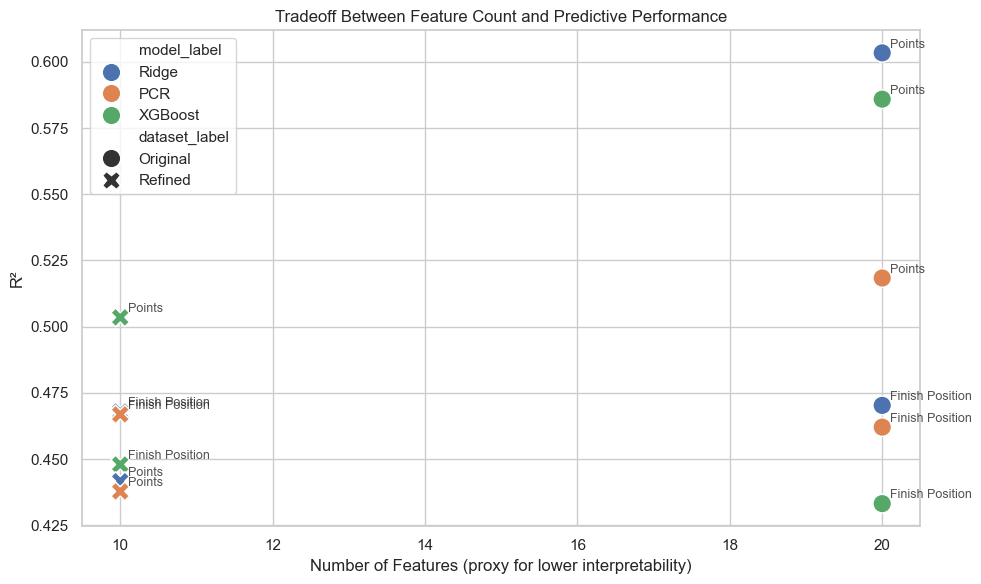

In [75]:
# Feature count by dataset
feature_count_map = {
    "original": len(original_features),
    "refined": len(refined_features)
}

tradeoff_df = results_plot.copy()
tradeoff_df["feature_count"] = tradeoff_df["dataset"].map(feature_count_map)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tradeoff_df,
    x="feature_count",
    y="r2",
    hue="model_label",
    style="dataset_label",
    s=180
)

for _, row in tradeoff_df.iterrows():
    plt.text(
        row["feature_count"] + 0.1,
        row["r2"] + 0.002,
        f'{row["target_label"]}',
        fontsize=9,
        alpha=0.8
    )

plt.title("Tradeoff Between Feature Count and Predictive Performance")
plt.xlabel("Number of Features (proxy for lower interpretability)")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

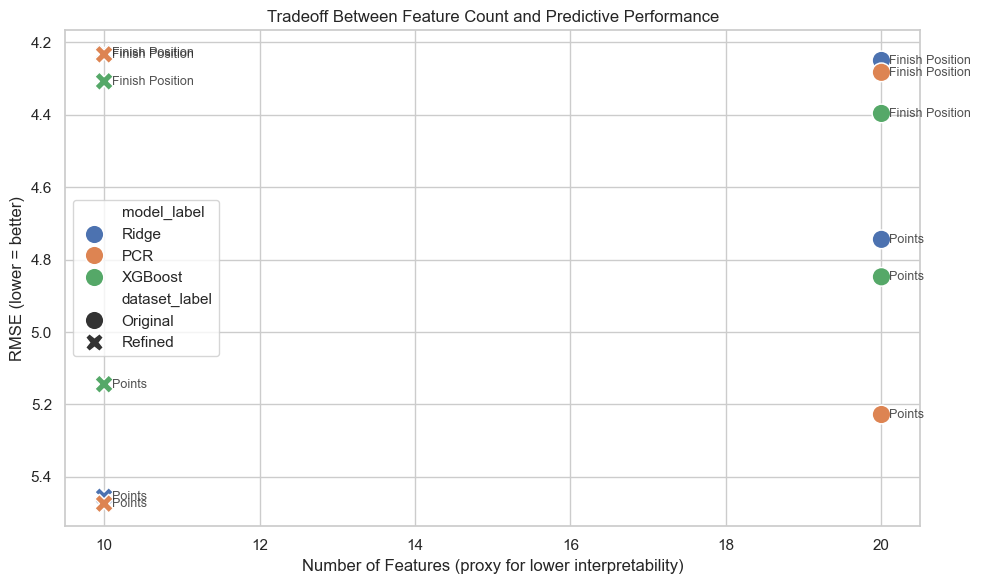

In [87]:
# Feature count by dataset
feature_count_map = {
    "original": len(original_features),
    "refined": len(refined_features)
}

tradeoff_df = results_plot.copy()
tradeoff_df["feature_count"] = tradeoff_df["dataset"].map(feature_count_map)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tradeoff_df,
    x="feature_count",
    y="rmse",
    hue="model_label",
    style="dataset_label",
    s=180
)

for _, row in tradeoff_df.iterrows():
    plt.text(
        row["feature_count"] + 0.1,
        row["rmse"] + 0.01,
        f'{row["target_label"]}',
        fontsize=9,
        alpha=0.8
    )

plt.title("Tradeoff Between Feature Count and Predictive Performance")
plt.xlabel("Number of Features (proxy for lower interpretability)")
plt.ylabel("RMSE (lower = better)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

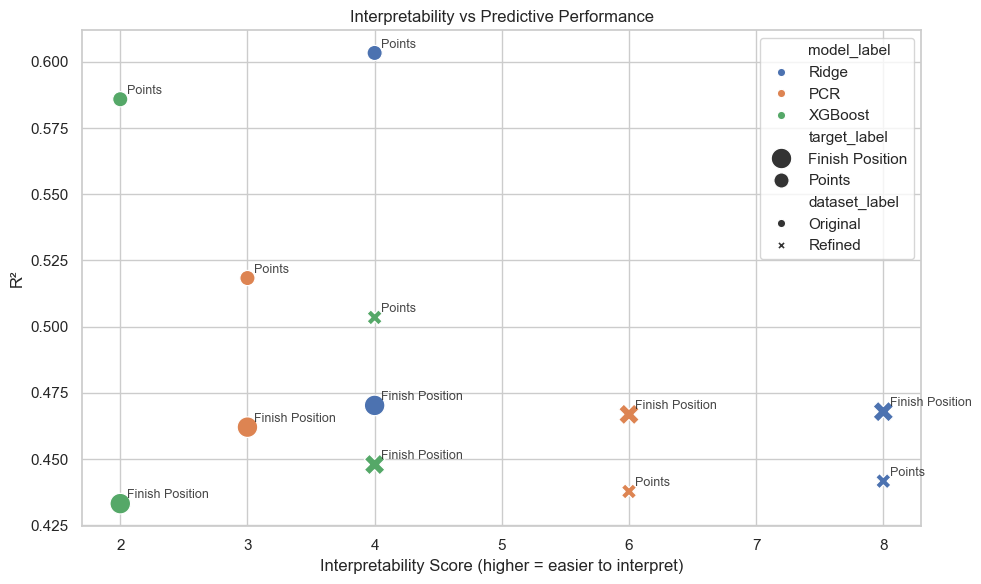

In [76]:
interpretability_score_map = {
    ("original", "linreg"): 5,
    ("original", "ridge"): 4,
    ("original", "pcr"): 3,
    ("original", "xgboost"): 2,
    ("refined", "linreg"): 9,
    ("refined", "ridge"): 8,
    ("refined", "pcr"): 6,
    ("refined", "xgboost"): 4
}

tradeoff_df2 = results_plot.copy()
tradeoff_df2["interpretability_score"] = tradeoff_df2.apply(
    lambda r: interpretability_score_map.get((r["dataset"], r["model"]), np.nan),
    axis=1
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tradeoff_df2,
    x="interpretability_score",
    y="r2",
    hue="model_label",
    style="dataset_label",
    size="target_label",
    sizes=(120, 220)
)

for _, row in tradeoff_df2.iterrows():
    plt.text(
        row["interpretability_score"] + 0.05,
        row["r2"] + 0.002,
        row["target_label"],
        fontsize=9,
        alpha=0.85
    )

plt.title("Interpretability vs Predictive Performance")
plt.xlabel("Interpretability Score (higher = easier to interpret)")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

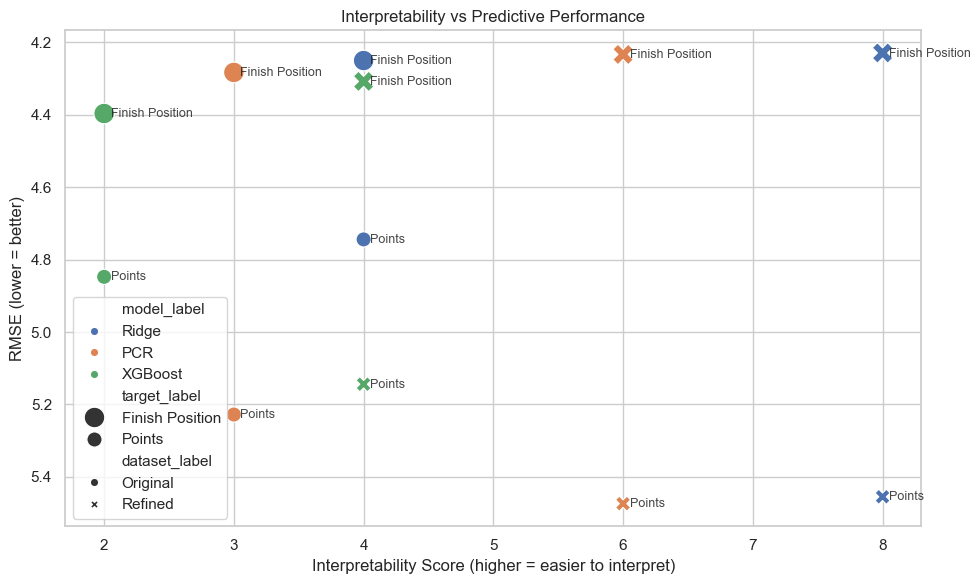

In [88]:
interpretability_score_map = {
    ("original", "linreg"): 5,
    ("original", "ridge"): 4,
    ("original", "pcr"): 3,
    ("original", "xgboost"): 2,
    ("refined", "linreg"): 9,
    ("refined", "ridge"): 8,
    ("refined", "pcr"): 6,
    ("refined", "xgboost"): 4
}

tradeoff_df2 = results_plot.copy()
tradeoff_df2["interpretability_score"] = tradeoff_df2.apply(
    lambda r: interpretability_score_map.get((r["dataset"], r["model"]), np.nan),
    axis=1
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tradeoff_df2,
    x="interpretability_score",
    y="rmse",
    hue="model_label",
    style="dataset_label",
    size="target_label",
    sizes=(120, 220)
)

for _, row in tradeoff_df2.iterrows():
    plt.text(
        row["interpretability_score"] + 0.05,
        row["rmse"] + 0.01,
        row["target_label"],
        fontsize=9,
        alpha=0.85
    )

plt.title("Interpretability vs Predictive Performance")
plt.xlabel("Interpretability Score (higher = easier to interpret)")
plt.ylabel("RMSE (lower = better)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [77]:
stability_accuracy_df = (
    cv_df
    .groupby(["target", "dataset", "model"], as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std")
    )
)

stability_accuracy_df["dataset_label"] = stability_accuracy_df["dataset"].map({
    "original": "Original",
    "refined": "Refined"
})

stability_accuracy_df["model_label"] = stability_accuracy_df["model"].map({
    "linreg": "Linear Regression",
    "ridge": "Ridge",
    "pcr": "PCR",
    "xgboost": "XGBoost"
}).fillna(stability_accuracy_df["model"])

stability_accuracy_df["target_label"] = stability_accuracy_df["target"].map({
    "finish_position": "Finish Position",
    "points": "Points"
}).fillna(stability_accuracy_df["target"])

stability_accuracy_df

,target,dataset,model,rmse_mean,rmse_std,dataset_label,model_label,target_label
0,finish_position,original,pcr,4.996282,0.053118,Original,PCR,Finish Position
1,finish_position,original,ridge,4.993408,0.053407,Original,Ridge,Finish Position
2,finish_position,original,xgboost,5.050925,0.057731,Original,XGBoost,Finish Position
3,finish_position,refined,pcr,5.036336,0.085369,Refined,PCR,Finish Position
4,finish_position,refined,ridge,5.035621,0.083181,Refined,Ridge,Finish Position
5,finish_position,refined,xgboost,5.110812,0.091754,Refined,XGBoost,Finish Position
6,points,original,pcr,4.494070,0.077513,Original,PCR,Points
7,points,original,ridge,4.127772,0.062487,Original,Ridge,Points
8,points,original,xgboost,4.038863,0.080774,Original,XGBoost,Points
9,points,refined,pcr,4.890584,0.060719,Refined,PCR,Points


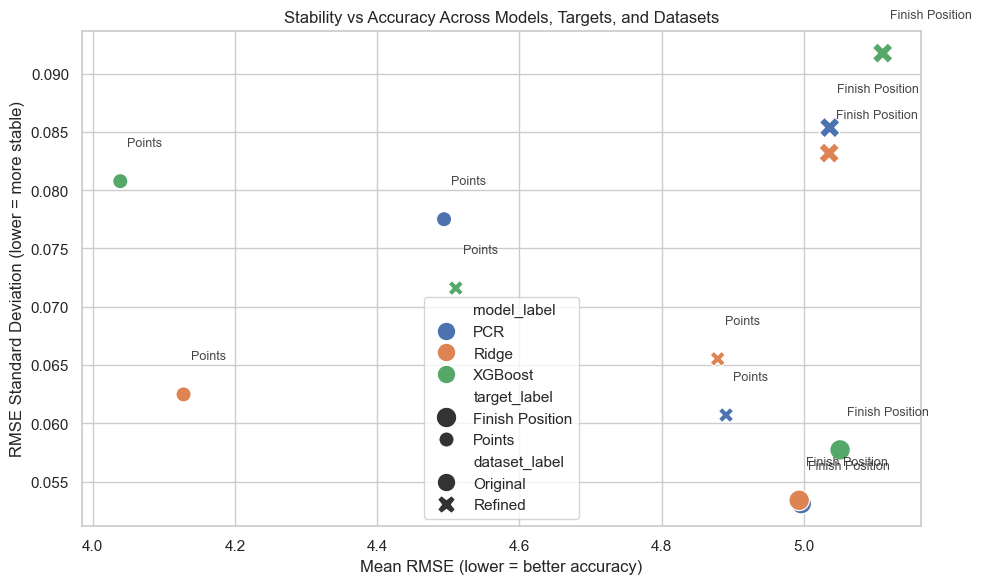

In [78]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=stability_accuracy_df,
    x="rmse_mean",
    y="rmse_std",
    hue="model_label",
    style="dataset_label",
    size="target_label",
    sizes=(120, 220),
    s=180
)

for _, row in stability_accuracy_df.iterrows():
    plt.text(
        row["rmse_mean"] + 0.01,
        row["rmse_std"] + 0.003,
        row["target_label"],
        fontsize=9,
        alpha=0.85
    )

plt.title("Stability vs Accuracy Across Models, Targets, and Datasets")
plt.xlabel("Mean RMSE (lower = better accuracy)")
plt.ylabel("RMSE Standard Deviation (lower = more stable)")
plt.tight_layout()
plt.show()

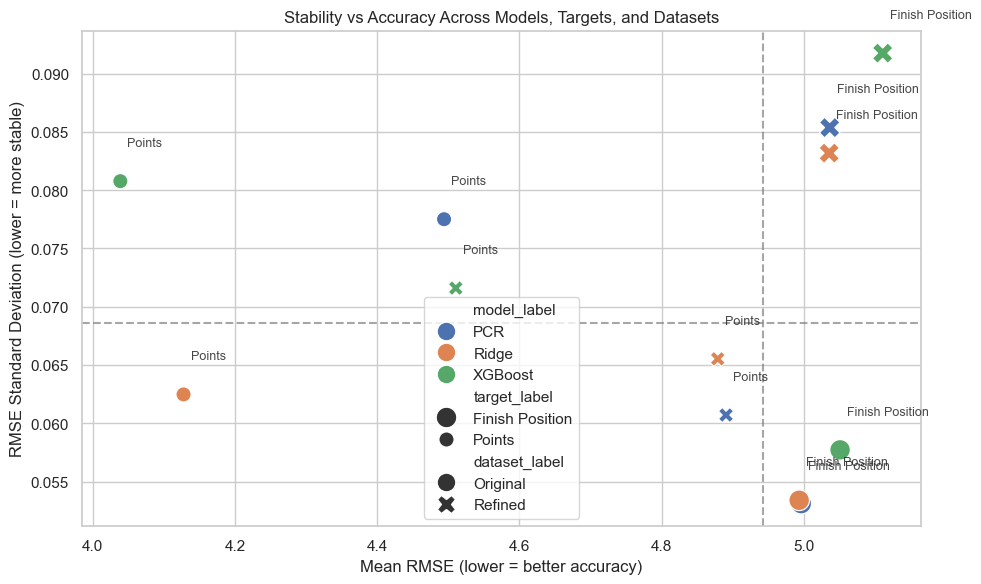

In [79]:
x_mid = stability_accuracy_df["rmse_mean"].median()
y_mid = stability_accuracy_df["rmse_std"].median()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=stability_accuracy_df,
    x="rmse_mean",
    y="rmse_std",
    hue="model_label",
    style="dataset_label",
    size="target_label",
    sizes=(120, 220),
    s=180
)

plt.axvline(x_mid, linestyle="--", color="gray", alpha=0.7)
plt.axhline(y_mid, linestyle="--", color="gray", alpha=0.7)

for _, row in stability_accuracy_df.iterrows():
    plt.text(
        row["rmse_mean"] + 0.01,
        row["rmse_std"] + 0.003,
        row["target_label"],
        fontsize=9,
        alpha=0.85
    )

plt.title("Stability vs Accuracy Across Models, Targets, and Datasets")
plt.xlabel("Mean RMSE (lower = better accuracy)")
plt.ylabel("RMSE Standard Deviation (lower = more stable)")
plt.tight_layout()
plt.show()

In [80]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use refined features by default for PCA story
pca_feature_set = refined_features

pca_df = df[pca_feature_set].copy()

for col in pca_df.columns:
    pca_df[col] = pd.to_numeric(pca_df[col], errors="coerce")

pca_df = pca_df.dropna().copy()

X_scaled = StandardScaler().fit_transform(pca_df)

pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1

print("Components to reach 90% variance:", n_components_90)

Components to reach 90% variance: 7


In [81]:
best_perf_df = (
    results_plot
    .groupby(["target", "dataset"], as_index=False)
    .apply(lambda g: g.loc[g["r2"].idxmax()])
    .reset_index(drop=True)
)

best_perf_df["dataset_label"] = best_perf_df["dataset"].map({
    "original": "Original",
    "refined": "Refined"
})
best_perf_df["target_label"] = best_perf_df["target"].map({
    "finish_position": "Finish Position",
    "points": "Points"
})
best_perf_df["model_label"] = best_perf_df["model"].map({
    "linreg": "Linear Regression",
    "ridge": "Ridge",
    "pcr": "PCR",
    "xgboost": "XGBoost"
}).fillna(best_perf_df["model"])

best_perf_df[["target_label", "dataset_label", "model_label", "r2", "rmse"]]

/var/folders/cg/wc2pq_yj52nbzwtdflk50zzc0000gn/T/ipykernel_56900/1164625408.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g["r2"].idxmax()])


,target_label,dataset_label,model_label,r2,rmse
0,Finish Position,Original,Ridge,0.470250,4.249857
1,Finish Position,Refined,Ridge,0.467889,4.228889
2,Points,Original,Ridge,0.603373,4.744000
3,Points,Refined,XGBoost,0.503480,5.144032


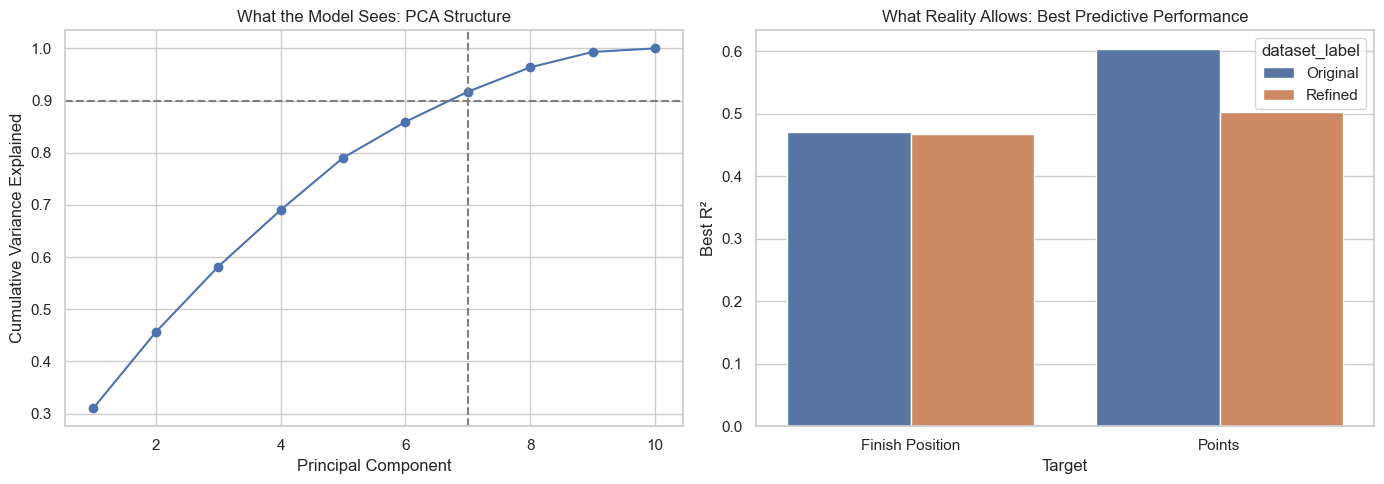

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA explained variance
axes[0].plot(range(1, len(cum_var) + 1), cum_var, marker="o")
axes[0].axhline(0.90, linestyle="--", color="gray")
axes[0].axvline(n_components_90, linestyle="--", color="gray")
axes[0].set_title("What the Model Sees: PCA Structure")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Cumulative Variance Explained")

# Right: Best predictive performance
sns.barplot(
    data=best_perf_df,
    x="target_label",
    y="r2",
    hue="dataset_label",
    ax=axes[1]
)
axes[1].set_title("What Reality Allows: Best Predictive Performance")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Best R²")

plt.tight_layout()
plt.show()xx

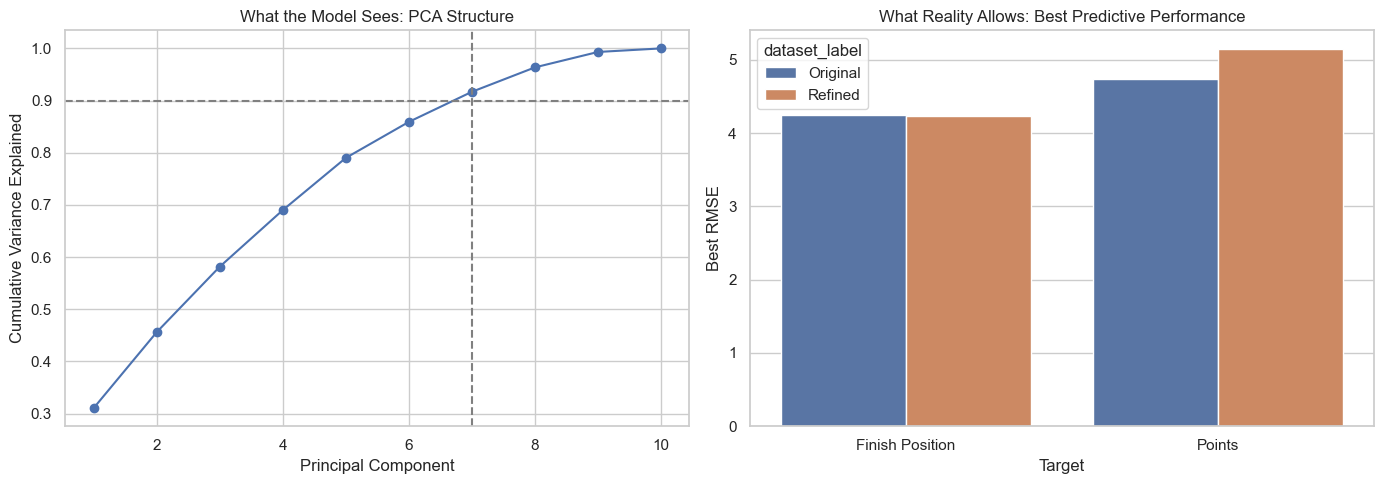

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA explained variance
axes[0].plot(range(1, len(cum_var) + 1), cum_var, marker="o")
axes[0].axhline(0.90, linestyle="--", color="gray")
axes[0].axvline(n_components_90, linestyle="--", color="gray")
axes[0].set_title("What the Model Sees: PCA Structure")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Cumulative Variance Explained")

# Right: Best predictive performance
sns.barplot(
    data=best_perf_df,
    x="target_label",
    y="rmse",
    hue="dataset_label",
    ax=axes[1]
)
axes[1].set_title("What Reality Allows: Best Predictive Performance")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Best RMSE")

plt.tight_layout()
plt.show()

## Key Takeaways

- The refined feature set reduces redundancy and improves interpretability.
- Bootstrap confidence intervals help distinguish genuine performance differences from sampling noise.
- Cross-validation and rolling-origin validation show whether model quality is stable across resamples and time periods.
- Permutation importance reveals which features matter consistently, not just in a single train/test split.
- Final model selection should prioritize stability and robustness, not just best-case performance.

In [41]:
import sys
import subprocess

subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout

'anyio==4.12.1\nappnope==0.1.4\nargon2-cffi==25.1.0\nargon2-cffi-bindings==25.1.0\narrow==1.4.0\nasttokens==2.4.1\nasync-lru==2.1.0\nattrs==25.4.0\nbabel==2.18.0\nbeautifulsoup4==4.14.3\nbleach==6.3.0\ncertifi==2024.7.4\ncffi==2.0.0\ncharset-normalizer==3.4.4\nclick==8.1.7\ncomm==0.2.2\ncontourpy==1.2.1\ncycler==0.12.1\ndebugpy==1.8.2\ndecorator==5.1.1\ndefusedxml==0.7.1\nexecuting==2.0.1\nfastjsonschema==2.21.2\nfonttools==4.53.1\nfqdn==1.5.1\nghp-import==2.1.0\nh11==0.16.0\nhttpcore==1.0.9\nhttpx==0.28.1\nidna==3.11\nipykernel==6.29.5\nipython==8.26.0\nisoduration==20.11.0\njedi==0.19.1\nJinja2==3.1.4\njoblib==1.5.3\njson5==0.13.0\njsonpointer==3.0.0\njsonschema==4.26.0\njsonschema-specifications==2025.9.1\njupyter-events==0.12.0\njupyter-lsp==2.3.0\njupyter_client==8.6.2\njupyter_core==5.7.2\njupyter_server==2.17.0\njupyter_server_terminals==0.5.4\njupyterlab==4.5.4\njupyterlab_pygments==0.3.0\njupyterlab_server==2.28.0\nkiwisolver==1.4.5\nlark==1.3.1\nMarkdown==3.6\nMarkupSafe==2.1

In [42]:
reqs = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True
).stdout

with open("requirements.txt", "w") as f:
    f.write(reqs)

print("requirements.txt updated")

requirements.txt updated


## Next Steps ##

- a final “best model” notebook
- a simulation notebook
- a forecasting notebook for future races